# Pill Detection Pipeline

YOLO 기반 알약 탐지 파이프라인입니다.

**주요 흐름:**
1. JSON 어노테이션 수집 → COCO 포맷 통합
2. GCI(Global Category Index) 생성 → category_id ↔ yolo_cls 매핑
3. YOLO 데이터셋 export (images + labels + dataset.yaml)
4. (옵션) 베이스라인 학습으로 파이프라인 검증
5. Optuna 하이퍼파라미터 탐색 → best params로 최종 재학습
6. 테스트 추론 → 제출 CSV 생성

**평가 지표:** mAP@\[0.75:0.95\] (IoU=0.75~0.95, step 0.05)


In [1]:
# 필요시 설치
# !pip -q install ultralytics==8.* pycocotools optuna pyyaml

# ============================================
# 공통 Import (중복 제거 + 미사용 함수 제거 완료)
# ============================================
import random, sys, signal, threading
import os, time, json, csv, re, glob, shutil, importlib
from pathlib import Path
from collections import defaultdict, Counter
from datetime import datetime
from tqdm import tqdm

# 수치/데이터 라이브러리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import matplotlib.image as mpimg

# YOLO & COCO
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Optuna
import optuna

# PyTorch
import torch

# 로컬 모듈 (실제 사용하는 함수만 import)
sys.path.append(str(Path(".").resolve()))
from pill_preprocess_v3_robust import (
    split_coco_by_image,
    resolve_image_path,
    write_split_list,
    write_dataset_yaml,
    save_coco_json,
    count_class_instances,
    compute_class_weight_from_coco,
    make_weighted_train_list
)
from pill_model_setup_v4_max4_fixed import CFG, set_seed, build_yolo_model, train_yolo


In [2]:
# =========================
# 한글 폰트 자동 설정 (Windows + macOS 혼용 기준)
# - Windows: Malgun Gothic(맑은 고딕)
# - macOS: AppleGothic
# - (fallback) NanumGothic / Noto Sans KR 계열
# =========================
import platform

def set_korean_font(verbose=True):
    try:
        from matplotlib import font_manager
        available = {f.name for f in font_manager.fontManager.ttflist}
    except Exception:
        available = set()

    sysname = platform.system().lower()

    if "windows" in sysname:
        candidates = ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Noto Sans KR"]
    elif "darwin" in sysname or "mac" in sysname:
        candidates = ["AppleGothic", "NanumGothic", "Noto Sans KR", "Noto Sans CJK KR"]
    else:
        candidates = ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR", "DejaVu Sans"]

    chosen = None
    for name in candidates:
        # available이 비어있으면(폰트 스캔 실패) 일단 첫 후보를 적용 시도
        if not available or name in available:
            chosen = name
            break

    if chosen:
        mpl.rcParams["font.family"] = chosen
    mpl.rcParams["axes.unicode_minus"] = False

    if verbose:
        print("OS:", platform.system())
        print("✅ Matplotlib font:", chosen)
        if available and chosen not in available:
            print("ℹ️ 선택된 폰트를 시스템에서 찾지 못했습니다. (그래도 렌더링은 될 수 있습니다)")
            print("   - Windows: '맑은 고딕' 설치 여부 확인")
            print("   - macOS: 기본 포함되는 AppleGothic 사용 권장")
    return chosen

_ = set_korean_font(verbose=True)


OS: Windows
✅ Matplotlib font: Malgun Gothic


In [3]:
# =========================
# 학습 중단 유틸리티 (GracefulStopper)
# - 파이참/Jupyter 중단 버튼(■) 또는 Ctrl+C를 누르면
#   현재 epoch 학습을 마친 뒤 안전하게 종료합니다.
# - Ultralytics가 SIGINT 핸들러를 덮어씌우는 문제를 우회하기 위해
#   signal 핸들러 + on_train_epoch_end 콜백을 함께 사용합니다.
# =========================

class GracefulStopper:
    """학습 중단을 안전하게 처리하는 유틸리티.

    사용법:
        stopper = GracefulStopper()
        stopper.attach(model)  # YOLO 모델에 콜백 등록

        model.train(...)       # 학습 시작

        if stopper.stopped:
            print("중단됨!")
    """

    def __init__(self):
        self.stopped = False
        self._stop_count = 0
        self._trainer_ref = None
        self._original_handler = None
        self._lock = threading.Lock()

    def _signal_handler(self, signum, frame):
        """SIGINT(Ctrl+C / 중단 버튼) 수신 시 호출됩니다."""
        with self._lock:
            self._stop_count += 1
            self.stopped = True

            if self._stop_count == 1:
                print("\n" + "=" * 80)
                print("⚠️  중단 신호 수신 — 현재 epoch 완료 후 안전하게 종료합니다.")
                print("    (즉시 강제 종료하려면 한 번 더 누르세요)")
                print("=" * 80)
                # trainer가 이미 할당되어 있으면 즉시 stop
                if self._trainer_ref is not None:
                    try:
                        self._trainer_ref.stop = True
                    except Exception:
                        pass
            else:
                # 두 번째 이상: 강제 종료
                print("\n⚠️  강제 종료합니다.")
                if self._original_handler and callable(self._original_handler):
                    self._original_handler(signum, frame)
                else:
                    raise KeyboardInterrupt

    def attach(self, model):
        """YOLO 모델에 signal 핸들러 + 콜백을 등록합니다."""
        self.stopped = False
        self._stop_count = 0
        self._trainer_ref = None

        # 1) SIGINT 핸들러 등록 (Ultralytics가 덮어씌우더라도 콜백이 백업)
        self._original_handler = signal.getsignal(signal.SIGINT)
        signal.signal(signal.SIGINT, self._signal_handler)

        # 2) on_train_epoch_end 콜백 — 매 epoch 끝마다 체크
        def _on_epoch_end(trainer):
            self._trainer_ref = trainer
            if self.stopped:
                trainer.stop = True

        # 3) on_train_start 콜백 — trainer 참조 확보 + SIGINT 재등록
        #    (Ultralytics가 train() 진입 시 핸들러를 다시 덮어씌울 수 있으므로)
        def _on_train_start(trainer):
            self._trainer_ref = trainer
            # Ultralytics가 덮어쓴 핸들러를 다시 우리 것으로 교체
            signal.signal(signal.SIGINT, self._signal_handler)

        # 콜백 등록 (중복 방지를 위해 reset 후 등록)
        try:
            model.reset_callbacks()
        except Exception:
            pass
        model.add_callback("on_train_start", _on_train_start)
        model.add_callback("on_train_epoch_end", _on_epoch_end)

        return self

    def detach(self):
        """원래 SIGINT 핸들러를 복원합니다."""
        if self._original_handler is not None:
            try:
                signal.signal(signal.SIGINT, self._original_handler)
            except Exception:
                signal.signal(signal.SIGINT, signal.default_int_handler)
            self._original_handler = None

    @property
    def summary(self):
        """중단 상태 요약을 딕셔너리로 반환합니다."""
        tr = self._trainer_ref
        info = {"stopped": self.stopped}
        if tr is not None:
            info["epoch"] = getattr(tr, "epoch", None)
            info["epochs"] = getattr(tr, "epochs", None)
            info["save_dir"] = str(getattr(tr, "save_dir", ""))
        return info

print("✅ GracefulStopper 준비 완료")


✅ GracefulStopper 준비 완료


In [4]:
# =========================
# 0) 설정 (이 셀만 수정하면 전체 파이프라인에 반영됩니다)
# =========================
cfg = CFG()

# (전역) Optuna 이후 최종 가중치 경로 (7-1 셀에서 설정)
FINAL_WEIGHTS = None

# -------------------------
# ✅ 데이터 경로 (py 파일 기준: root를 주고 하위 폴더까지 재귀 탐색)
# -------------------------
cfg.label_root = getattr(cfg, "label_root", "data/label_aug")
cfg.image_root = getattr(cfg, "image_root", "data/train_aug")

# (호환) 기존 변수명 유지
cfg.train_ann_dir = cfg.label_root
cfg.train_img_dir = cfg.image_root
cfg.test_img_dir  = getattr(cfg, "test_img_dir", "data/test_images")

cfg.train_ann_dirs = getattr(cfg, "train_ann_dirs", [cfg.label_root])
cfg.image_roots = getattr(cfg, "image_roots", [cfg.image_root])

# 이미지 기본 크기(일부 JSON에 width/height가 없을 때 bbox bounds 검증용)
cfg.image_width  = int(getattr(cfg, "image_width", 976))
cfg.image_height = int(getattr(cfg, "image_height", 1280))

# dataset_generator_v2_patched_final 기준 옵션
cfg.exclude_index_images = bool(getattr(cfg, "exclude_index_images", True))

# 출력 경로
cfg.yolo_dataset_dir = getattr(cfg, "yolo_dataset_dir", "yolo_pill_ds")
cfg.export_dir = getattr(cfg, "export_dir", "exports_pill")

# (선택) train57 기준 GCI를 이미 가지고 있으면 넣어주세요.
cfg.gci_train57_path = getattr(cfg, "gci_train57_path", "")

# -------------------------
# ✅ (중요) category_id 오프셋 보정
# -------------------------
cfg.shift_ann_subdir = getattr(cfg, "shift_ann_subdir", "train_annotations")
cfg.train_ann_cid_shift = int(getattr(cfg, "train_ann_cid_shift", -1))
cfg.apply_shift_only_to_subdir = bool(getattr(cfg, "apply_shift_only_to_subdir", True))

cfg.gci_filter_allowed_ids = bool(getattr(cfg, "gci_filter_allowed_ids", False))
cfg.submit_catid_offset = int(getattr(cfg, "submit_catid_offset", 1))
cfg.gci_force_light_scan = bool(getattr(cfg, "gci_force_light_scan", True))

# -------------------------
# ✅ Ultralytics train 설정
# -------------------------
cfg.split = 0.9
cfg.val_ratio = 0.1  # 단순하게 명시적 값 사용 (= 1.0 - split)

cfg.epochs = 100
cfg.patience = 10
cfg.imgsz = 640

cfg.batch = 16
cfg.workers = 0
cfg.amp = True

cfg.optimizer = "AdamW"
cfg.lr0 = 0.0005

# 증강(현실적 노이즈 위주)
cfg.hsv_h = 0.0
cfg.hsv_s = 0.0
cfg.hsv_v = 0.0

cfg.degrees = 10.0
cfg.translate = 0.1
cfg.scale = 0.2

# hasattr 체크 없이 무조건 할당
#   - CFG에 이미 shear/perspective가 정의되어 있으므로 hasattr은 항상 True → 체크 무의미
#   - 의도가 "0으로 고정"이므로 직접 할당
cfg.shear = 0.0
cfg.perspective = 0.0

cfg.fliplr = 0.5
cfg.flipud = 0.5
cfg.mosaic = 0.25
cfg.mixup  = 0.0
cfg.erasing = 0.2

cfg.device = 0

# 실험 저장 경로
cfg.project = r"yolo_runs"
cfg.name = "pill_baseline_augdata"
cfg.save_period = 10

# (호환) 기존 코드에서 쓰던 변수명
cfg.work_dir = cfg.project
cfg.baseline_name = cfg.name
cfg.optuna_subdir = "optuna"

# Global Category Index(GCI)
cfg.force_apply_gci_remap = False
cfg.gci_output_dir = "global_category_index"
cfg.gci_json_path  = str(Path(cfg.gci_output_dir) / "global_category_index.json")
cfg.extra_ann_dir  = "data/extra_annotations_tmp"
cfg.gci_include_extra = False
cfg.gci_use_train_subset = True

cfg.local_categories_csv = str(Path(cfg.gci_output_dir) / "local_categories.csv")
cfg.global_category_index_csv = str(Path(cfg.gci_output_dir) / "global_category_index.csv")
cfg.use_local_gci_min_plus1 = True
cfg.overwrite_local_categories_csv = True

# Class weight / 불균형 보정
cfg.class_weight_enable = True
cfg.class_weight_json = str(Path(cfg.export_dir) / "class_weights.json")
cfg.class_weight_category_csv = str(Path(cfg.gci_output_dir) / "global_category_index.csv")
cfg.class_weight_submission_csv = ""
cfg.class_weight_count_threshold = 15

cfg.balance_enable = True
cfg.balance_extra_ratio = 0.30
cfg.balance_power = 1.0

# 도메인 제약/제출 설정
cfg.max_det_per_image = 4
cfg.submit_conf = float(getattr(cfg, "submit_conf", getattr(cfg, "conf", 0.0)))


# -------------------------
# ✅ Optuna 서브셋 설정 (NEW)
# - 전체 데이터로 Optuna를 돌리면 너무 오래 걸릴 때, 특정 폴더만 지정하여 빠르게 탐색
# - optuna_use_subset=False이면 전체 데이터(data_yaml)를 그대로 사용합니다.
# - optuna_use_subset=True이면 아래 폴더에서 서브셋을 만들어 탐색 → 최종 재학습은 전체 데이터로.
# -------------------------
cfg.optuna_use_subset = True  # ✅ True: 서브셋으로 Optuna / False: 전체 데이터로 Optuna

# (방법 1) 특정 폴더 지정 — 해당 폴더의 JSON/이미지만 사용
#   비워두면([]) 방법 2(랜덤 샘플링)로 자동 전환
cfg.optuna_ann_dirs    = []   # 예: ["data/label_aug/train01", "data/label_aug/train02"]
cfg.optuna_image_roots = []   # 예: ["data/train_aug/train01", "data/train_aug/train02"]

# (방법 2) 전체 데이터에서 랜덤 샘플링 — 위 폴더가 비어있을 때 사용
#   전체 이미지의 N%만 사용 (예: 0.3 = 30%)
cfg.optuna_sample_ratio = 0.3

# Optuna에서 탐색할 배치 사이즈 후보 목록
cfg.optuna_batch_sizes = [16]

# Optuna 서브셋 YOLO export 경로 (자동 생성됨)
cfg.optuna_dataset_dir = "yolo_pill_ds_optuna"

# Seed
set_seed(cfg.seed)
print(cfg)


CFG()


## 1) 어노테이션 로드 및 COCO 구성

- `label_root` 하위의 모든 `*.json`을 수집하고, `image_root`에서 이미지 경로를 인덱싱합니다.
- `category_id`는 `images[0].dl_idx`를 우선 사용하고, 없으면 `annotations[0].category_id`를 사용합니다.
- `train_annotations` 폴더의 JSON만 `category_id`에 오프셋(`cfg.train_ann_cid_shift`)을 적용합니다.
- `image_id` / `annotation_id`는 충돌 방지를 위해 내부적으로 재부여됩니다.


In [5]:
# =========================
# 1) (py 기준) JSON + 이미지 root에서 학습용 COCO 구성
# =========================

# IMG_EXTS를 파이프라인 전체에서 공유할 통일된 값으로 한 번만 정의
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def build_image_index(image_roots):
    index = {}
    dup = defaultdict(list)
    scanned = 0
    for root in image_roots:
        root = Path(root)
        if not root.exists():
            print("[IMG] skip missing:", root)
            continue
        for p in root.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                scanned += 1
                fn = p.name
                if fn not in index:
                    index[fn] = str(p)
                else:
                    dup[fn].append(str(p))
    return index, dup, scanned

def collect_json_paths(ann_dirs):
    out = []
    for d in ann_dirs:
        d = Path(d)
        if not d.exists():
            print("[JSON] skip missing:", d)
            continue
        out.extend(list(d.rglob("*.json")))
    return out

def load_gci_allowed_ids(cfg):
    for cand in [getattr(cfg, "gci_train57_path", ""), getattr(cfg, "gci_json_path", "")]:
        if cand and Path(cand).exists():
            with open(cand, "r", encoding="utf-8") as f:
                gci = json.load(f)
            allowed = set(int(k) for k in (gci.get("id_to_index") or {}).keys())
            return allowed, gci, str(cand)
    return None, None, ""

# _path_contains_subdir: 파이프라인 전체에서 이 정의만 사용
def _path_contains_subdir(p: Path, subdir: str) -> bool:
    s = str(p).replace("\\", "/").lower()
    sub = ("/" + str(subdir).strip("/").lower() + "/")
    return sub in s

# _extract_raw_category_id 함수 2개 제거
#   → 원래 정의만 되고 한 번도 호출되지 않았으므로, 인라인 로직만 유지

def normalize_category_id(raw_id, jf: Path, *, shift_subdir: str, shift_delta: int, apply_only: bool = True):
    try:
        v = int(raw_id)
    except Exception:
        return None, "bad"

    if apply_only and shift_subdir and _path_contains_subdir(jf, shift_subdir):
        vv = v + int(shift_delta)
        return vv, "shift_subdir"
    return v, "keep"


# 1) 이미지 인덱스
t0 = time.time()
IMAGE_INDEX, IMAGE_INDEX_DUP, scanned_imgs = build_image_index(cfg.image_roots)
print(f"[IMG] indexed={len(IMAGE_INDEX):,} | scanned_files={scanned_imgs:,} | dup_names={len(IMAGE_INDEX_DUP):,} | {time.time()-t0:.1f}s")
if len(IMAGE_INDEX_DUP) > 0:
    sample = list(IMAGE_INDEX_DUP.items())[:5]
    print("[IMG] duplicate filename examples (kept first):")
    for fn, paths in sample:
        print(" -", fn, "dup_count=", len(paths)+1)

# 2) JSON 수집
json_paths = collect_json_paths(cfg.train_ann_dirs)
print("[JSON] num_json_files:", f"{len(json_paths):,}")

# 3) train57(GCI) 로드(있으면)
allowed_ids, gci_ref, gci_used_path = load_gci_allowed_ids(cfg)
if allowed_ids is None:
    print("[GCI] train57 not provided. category_id 필터링은 생략됩니다.")
else:
    print(f"[GCI] train57 loaded: {gci_used_path} | allowed_ids={len(allowed_ids)}")

# 4) JSON -> COCO 생성
shift_subdir = getattr(cfg, "shift_ann_subdir", "train_annotations")
shift_delta = int(getattr(cfg, "train_ann_cid_shift", -1))
apply_only = bool(getattr(cfg, "apply_shift_only_to_subdir", True))
gci_filter_allowed = bool(getattr(cfg, "gci_filter_allowed_ids", False))

invalid = defaultdict(int)
stats = defaultdict(int)

imgid_by_name = {}
images = []
annotations = []
next_img_id = 1
next_ann_id = 1

seen_bbox = set()

for jf in json_paths:
    try:
        with open(jf, "r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception:
        invalid["json_read_fail"] += 1
        continue

    img_meta = (data.get("images") or [{}])[0]
    ann_list = data.get("annotations") or []
    if not ann_list:
        invalid["no_annotations"] += 1
        continue

    ann = ann_list[0]

    # file_name
    fn_raw = img_meta.get("file_name") or ann.get("file_name") or data.get("file_name")
    if not fn_raw:
        invalid["missing_file_name"] += 1
        continue
    file_name = Path(str(fn_raw)).name

    if bool(getattr(cfg, "exclude_index_images", True)) and ("_index" in file_name):
        invalid["_index_image"] += 1
        continue

    # bbox
    bbox = ann.get("bbox", None)
    if not (isinstance(bbox, (list, tuple)) and len(bbox) == 4):
        invalid["missing_bbox"] += 1
        continue
    try:
        x, y, w, h = map(float, bbox)
    except Exception:
        invalid["non_numeric_bbox"] += 1
        continue
    if w <= 0 or h <= 0:
        invalid["degenerate_bbox"] += 1
        continue

    W = float(img_meta.get("width", getattr(cfg, "image_width", 976)))
    H = float(img_meta.get("height", getattr(cfg, "image_height", 1280)))

    if (x < 0) or (y < 0) or (x + w > W + 1e-3) or (y + h > H + 1e-3):
        invalid["out_of_bounds"] += 1
        continue

    # category_id (dl_idx 우선)
    raw_id = img_meta.get("dl_idx", None)
    if raw_id is None or str(raw_id).strip() == "":
        raw_id = ann.get("category_id", None)
    if raw_id is None:
        invalid["missing_category_id"] += 1
        continue

    cat_id, cat_tag = normalize_category_id(raw_id, jf, shift_subdir=shift_subdir, shift_delta=shift_delta, apply_only=apply_only)
    if cat_id is None:
        invalid["bad_category_id"] += 1
        continue
    stats[f"cat_norm_{cat_tag}"] += 1

    if int(cat_id) < 0:
        invalid["negative_category_id"] += 1
        continue

    if (allowed_ids is not None) and gci_filter_allowed and (int(cat_id) not in allowed_ids):
        invalid["not_in_train57"] += 1
        continue
    
    img_path = IMAGE_INDEX.get(file_name, None)
    if not img_path or not Path(img_path).exists():
        invalid["missing_image_file"] += 1
        continue

    # 중복 bbox 제거
    key = (file_name, int(cat_id), round(x, 3), round(y, 3), round(w, 3), round(h, 3))
    if key in seen_bbox:
        invalid["duplicate_bbox"] += 1
        continue
    seen_bbox.add(key)

    if file_name not in imgid_by_name:
        imgid_by_name[file_name] = next_img_id
        images.append({
            "id": next_img_id,
            "file_name": file_name,
            "width": int(W),
            "height": int(H),
            "source_path": img_path,
        })
        next_img_id += 1

    image_id = imgid_by_name[file_name]
    annotations.append({
        "id": next_ann_id,
        "image_id": image_id,
        "category_id": int(cat_id),
        "bbox": [x, y, w, h],
        "area": float(w * h),
        "iscrowd": 0,
        "source_json": str(jf),
    })
    next_ann_id += 1

# categories 구성
categories = []
if gci_ref is not None:
    cat_map = gci_ref.get("category_map") or {}
    for cid in sorted({a["category_id"] for a in annotations}):
        name = None
        try:
            name = (cat_map.get(str(cid)) or {}).get("category_name")
        except Exception:
            name = None
        categories.append({"id": int(cid), "name": name or str(cid)})
else:
    for cid in sorted({a["category_id"] for a in annotations}):
        categories.append({"id": int(cid), "name": str(cid)})

coco = {"images": images, "annotations": annotations, "categories": categories}

print("=" * 80)
print("[BUILD] images:", f"{len(images):,}", "| annotations:", f"{len(annotations):,}", "| categories:", len(categories))
print("[BUILD] cat_norm_stats:", dict(sorted(stats.items(), key=lambda x: -x[1])))
print("[BUILD] invalid_counts:", dict(sorted(invalid.items(), key=lambda x: -x[1])))

coco_all = coco


[IMG] indexed=16,243 | scanned_files=16,243 | dup_names=0 | 0.9s
[JSON] num_json_files: 46,705
[GCI] train57 loaded: global_category_index\global_category_index.json | allowed_ids=118
[BUILD] images: 12,219 | annotations: 46,453 | categories: 118
[BUILD] cat_norm_stats: {'cat_norm_keep': 45709, 'cat_norm_shift_subdir': 771}
[BUILD] invalid_counts: {'missing_bbox': 163, 'out_of_bounds': 61, 'missing_image_file': 27, 'json_read_fail': 1}


In [6]:
# =========================
# 1-1) COCO 데이터 사후 검증 (간단 통계)
# 기존에 Cell 5와 완전히 동일한 검증(bbox/중복/area)을 중복 수행하던 셀을 제거하고,
#          대신 빌드 결과의 간단한 통계만 출력합니다.
# =========================

ann_per_img = Counter(a["image_id"] for a in coco["annotations"])
cat_dist = Counter(a["category_id"] for a in coco["annotations"])

print(f"[VERIFY] images: {len(coco['images']):,} | annotations: {len(coco['annotations']):,} | categories: {len(coco['categories'])}")
print(f"[VERIFY] ann/image: min={min(ann_per_img.values())}, max={max(ann_per_img.values())}, mean={sum(ann_per_img.values())/len(ann_per_img):.1f}")
print(f"[VERIFY] top 5 categories by count: {cat_dist.most_common(5)}")


[VERIFY] images: 12,219 | annotations: 46,453 | categories: 118
[VERIFY] ann/image: min=1, max=6, mean=3.8
[VERIFY] top 5 categories by count: [(16547, 1362), (16550, 1335), (16231, 822), (16261, 819), (20237, 641)]


## 1.5) Global Category Index (GCI)

- 전체 어노테이션의 `category_id`를 `global_index (0..K-1)`로 통일합니다.
- YOLO 라벨(txt)에는 `global_index`를 class로 기록합니다.
- 제출 CSV에서는 `global_index → category_id`로 역매핑하여 원본 ID를 제출합니다.


In [7]:
# =========================
# 1.5) Global Category Index(GCI) 생성/로드
# - gci_generator.py 로직을 우선 사용하고, 실패하면(노트북/윈도우 병렬 이슈 등)
#   단일 프로세스 "light scan"으로 fallback 합니다.
# =========================

# _path_contains_subdir는 Cell 5에서 이미 정의됨 → 중복 제거

def build_gci_light(annotation_dirs, out_dir, *, shift_subdir=None, shift_delta=0):
    # 단일 프로세스 스캔(Fallback)
    # - cat_id: images[0].dl_idx 우선, 없으면 annotations[0].category_id 사용
    # - cat_name: images[0].dl_name 사용(없으면 'Unknown')
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    category_data = {}  # cat_id -> info
    dataset_stats = {}
    total_json = 0

    for ann_dir in annotation_dirs:
        ann_dir = Path(ann_dir)
        if not ann_dir.exists():
            print("[GCI] skip missing:", ann_dir)
            continue

        ds_name = ann_dir.name
        ds_total = 0
        ds_counts = {}

        for jf in ann_dir.rglob("*.json"):
            total_json += 1
            try:
                with open(jf, "r", encoding="utf-8") as f:
                    data = json.load(f)

                img_meta = (data.get("images") or [{}])[0]
                ann_list = data.get("annotations") or []
                if not ann_list:
                    continue

                dl_idx = img_meta.get("dl_idx")
                if dl_idx and str(dl_idx).strip():
                    cat_id = int(dl_idx)
                else:
                    cat_id = ann_list[0].get("category_id")
                    if cat_id is None:
                        continue
                    cat_id = int(cat_id)

                # (요청) train_annotations 하위 JSON만 category_id 오프셋 적용
                if shift_delta and shift_subdir and _path_contains_subdir(jf, shift_subdir):
                    cat_id = int(cat_id) + int(shift_delta)

                cat_name = img_meta.get("dl_name", "Unknown")
                k = len(ann_list)

            except Exception:
                continue

            if cat_id not in category_data:
                category_data[cat_id] = {
                    "category_id": cat_id,
                    "category_name": cat_name,
                    "dl_idx": str(dl_idx) if dl_idx else "",
                    "count": 0,
                    "datasets": {},
                }

            category_data[cat_id]["count"] += k
            category_data[cat_id]["datasets"][ds_name] = category_data[cat_id]["datasets"].get(ds_name, 0) + k

            ds_total += k
            ds_counts[cat_id] = ds_counts.get(cat_id, 0) + k

        dataset_stats[ds_name] = {
            "total_annotations": ds_total,
            "unique_categories": len(ds_counts),
            "category_counts": ds_counts,
        }

    sorted_ids = sorted(category_data.keys())
    index_to_id = {i: cid for i, cid in enumerate(sorted_ids)}
    id_to_index = {cid: i for i, cid in index_to_id.items()}
    total_ann = sum(category_data[cid]["count"] for cid in category_data)

    json_data = {
        "metadata": {
            "total_categories": len(sorted_ids),
            "total_annotations": total_ann,
            "total_datasets": len(dataset_stats),
            "index_range": f"0-{len(sorted_ids)-1}",
            "scanned_json_files": total_json,
        },
        "category_map": {
            str(cid): {**category_data[cid], "datasets": category_data[cid]["datasets"]}
            for cid in category_data
        },
        "index_to_id": {str(k): v for k, v in index_to_id.items()},
        "id_to_index": {str(k): v for k, v in id_to_index.items()},
        "dataset_stats": dataset_stats,
    }

    out_json = out_dir / "global_category_index.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(json_data, f, ensure_ascii=False, indent=2)

    # yolo_classes.txt (global_index 순서)
    out_classes = out_dir / "yolo_classes.txt"
    with open(out_classes, "w", encoding="utf-8") as f:
        for i in range(len(sorted_ids)):
            cid = index_to_id[i]
            f.write(category_data[cid]["category_name"] + "\n")

    # csv (요약)
    rows = []
    for i, cid in enumerate(sorted_ids):
        info = category_data[cid]
        rows.append({
            "category_id": cid,
            "global_index": i,
            "category_name": info["category_name"],
            "dl_idx": info.get("dl_idx", ""),
            "total_count": info["count"],
        })
    pd.DataFrame(rows).to_csv(out_dir / "global_category_index.csv", index=False, encoding="utf-8-sig")

    print(f"[GCI] light scan saved: {out_json} (K={len(sorted_ids)})")
    return str(out_json)


def ensure_gci(annotation_dirs, out_dir, force=False):
    # gci_generator.py의 GCIBuilder를 우선 사용하고, 문제 생기면 build_gci_light로 fallback
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_json = out_dir / "global_category_index.json"

    # (요청) train_annotations 오프셋이 있는 경우, 학습/제출과 일관성을 위해 light scan을 강제합니다.
    shift_subdir = getattr(cfg, "shift_ann_subdir", "train_annotations")
    shift_delta = int(getattr(cfg, "train_ann_cid_shift", 0))
    force_light = bool(getattr(cfg, "gci_force_light_scan", False)) or (shift_delta != 0)

    if force_light:
        return build_gci_light(annotation_dirs, out_dir, shift_subdir=shift_subdir, shift_delta=shift_delta)

    if out_json.exists() and not force:
        return str(out_json)

    # 1) gci_generator.py 시도
    try:
        gci_mod = importlib.import_module("gci_generator")
        if hasattr(gci_mod, "GCIBuilder"):
            builder = gci_mod.GCIBuilder(annotation_dirs=annotation_dirs, output_dir=str(out_dir))
            _ = builder.run()
            if out_json.exists():
                print("[GCI] generated via gci_generator.py:", out_json)
                return str(out_json)
    except Exception as e:
        print("[GCI] gci_generator.py 실패 -> fallback light scan:", repr(e))

    # 2) fallback
    return build_gci_light(annotation_dirs, out_dir, shift_subdir=getattr(cfg, "shift_ann_subdir", "train_annotations"), shift_delta=int(getattr(cfg, "train_ann_cid_shift", 0)))


# ---- annotation_dirs 구성: train_annotations만 (요청: train annotation 기반) ----
ann_dirs = [str(Path(d)) for d in getattr(cfg, 'train_ann_dirs', [cfg.train_ann_dir])]

# (옵션) extra annotations를 GCI에 함께 반영할지
extra_ann_dir = Path(getattr(cfg, "extra_ann_dir", "data/extra_annotations_tmp"))
if bool(getattr(cfg, "gci_include_extra", False)) and extra_ann_dir.exists():
    ann_dirs.append(str(extra_ann_dir))
else:
    # 기본은 train_only
    if extra_ann_dir.exists():
        print("[GCI] extra_ann_dir exists but excluded (cfg.gci_include_extra=False):", extra_ann_dir)
    else:
        print("[GCI] extra_ann_dir not found (ok):", extra_ann_dir)

# ---- 생성/로드 ----

gci_json_path = ensure_gci(ann_dirs, getattr(cfg, "gci_output_dir", "global_category_index"), force=False)
cfg.gci_json_path = gci_json_path

# ---- export_dir에도 복사(제출 CSV 셀에서 찾기 쉽게) ----
export_dir = Path(getattr(cfg, "export_dir", "exports_pill"))
export_dir.mkdir(parents=True, exist_ok=True)
try:
    shutil.copy2(gci_json_path, export_dir / "global_category_index.json")
    print("[GCI] copied to export_dir:", export_dir / "global_category_index.json")
except Exception as e:
    print("[GCI] copy to export_dir failed:", e)

# ---- 요약 ----
with open(gci_json_path, "r", encoding="utf-8") as f:
    _gci = json.load(f)

print("[GCI] total_categories:", _gci["metadata"]["total_categories"])
print("[GCI] total_annotations:", _gci["metadata"]["total_annotations"])
print("[GCI] scanned_json_files:", _gci["metadata"].get("scanned_json_files", "n/a"))


[GCI] extra_ann_dir not found (ok): data\extra_annotations_tmp
[GCI] light scan saved: global_category_index\global_category_index.json (K=118)
[GCI] copied to export_dir: exports_pill\global_category_index.json
[GCI] total_categories: 118
[GCI] total_annotations: 46704
[GCI] scanned_json_files: 46705


## 1.6) Class Weight 생성/로드

- 빈도 + confidence 기반 클래스 가중치를 계산합니다.
- Ultralytics는 `class_weights`를 loss에 직접 반영하지 않으므로, `train.txt` 오버샘플링 방식으로 적용합니다.
- `cfg.class_weight_category_csv` + `cfg.class_weight_submission_csv`가 모두 있으면 가중치를 생성하고, 없으면 기존 파일을 로드합니다.


In [8]:
# =========================
# class_weight.py 로직(핵심) 통합
# - category_csv + submission_csv가 둘 다 있을 때 class_weights.json 생성
# - 없으면(또는 일부만 있으면) 기존 파일 로드만 수행
# =========================

def calculate_class_weights(category_csv: str, submission_csv: str, output_json: str = "class_weights.json", *, count_th: int = 15):
    df_cat = pd.read_csv(category_csv)
    df_sub = pd.read_csv(submission_csv)

    df = df_cat.merge(df_sub[["category_id", "score_mean_base"]], on="category_id", how="left")

def load_class_weight_json(weights_json: str, nc: int | None = None):
    with open(weights_json, "r", encoding="utf-8") as f:
        d = json.load(f)
    # key가 str/int 섞여도 robust
    dd = {int(k): float(v) for k, v in d.items()}
    if nc is None:
        return dd
    w = np.ones(int(nc), dtype=np.float32)
    for k, v in dd.items():
        if 0 <= k < nc:
            w[k] = float(v)
    return w

# ---- cfg 기본 경로 자동 채움 ----
if not getattr(cfg, "class_weight_json", ""):
    cfg.class_weight_json = str(Path(getattr(cfg, "work_dir", ".")) / "class_weights.json")

# (권장) category_csv 기본값: GCI csv (존재할 때)
gci_csv = Path(getattr(cfg, "gci_output_dir", "global_category_index")) / "global_category_index.csv"
if (not getattr(cfg, "class_weight_category_csv", "")) and gci_csv.exists():
    cfg.class_weight_category_csv = str(gci_csv)

# submission_csv는 사용자가 갖고 있는 파일(예: score_mean_base 포함)로 지정해야 합니다.

print("cfg.class_weight_json:", cfg.class_weight_json)
print("cfg.class_weight_category_csv:", getattr(cfg, "class_weight_category_csv", ""))
print("cfg.class_weight_submission_csv:", getattr(cfg, "class_weight_submission_csv", ""))

# ---- 생성(가능할 때만) ----
if bool(getattr(cfg, "class_weight_enable", False)):
    cat_csv = getattr(cfg, "class_weight_category_csv", "")
    sub_csv = getattr(cfg, "class_weight_submission_csv", "")
    if cat_csv and sub_csv and Path(cat_csv).exists() and Path(sub_csv).exists():
        _w_dict, _dfw = calculate_class_weights(cat_csv, sub_csv, cfg.class_weight_json, count_th=int(getattr(cfg, "class_weight_count_threshold", 15)))
    else:
        # 파일이 이미 있으면 로드만
        if Path(cfg.class_weight_json).exists():
            print("[class_weight] found existing json -> will use on export balancing:", cfg.class_weight_json)
        else:
            print("[class_weight] skip generate (csv not found). json도 없음 -> COCO 빈도 기반 가중치로만 balance 가능")



def get_balance_class_weights(cfg, train_coco, *, nc: int | None = None):
    """학습 불균형 보정에 사용할 class weight를 하나의 규칙으로 결정합니다.
    우선순위:
      1) class_weight_json (있고 읽히면)
      2) COCO 빈도 기반 balanced weight
    """
    class_w = None
    wjson = getattr(cfg, "class_weight_json", "")
    if bool(getattr(cfg, "class_weight_enable", False)) and wjson and Path(wjson).exists():
        try:
            class_w = load_class_weight_json(wjson, nc=nc)
            print("[class_weight] using json:", wjson)
        except Exception as e:
            print("[class_weight] failed to load json -> fallback coco-balanced:", e)
            class_w = None

    if class_w is None:
        class_w = compute_class_weight_from_coco(train_coco, method="balanced")
        print("[class_weight] using COCO-balanced weights")

    return class_w

def print_class_balance_report(train_coco, class_w, *, topk: int = 10):
    cnt = count_class_instances(train_coco)
    total = sum(cnt.values())
    print(f"[class_balance] n_classes={len(cnt)} | n_ann={total}")
    top = sorted(cnt.items(), key=lambda x: x[1], reverse=True)[:topk]
    print("[class_balance] top by ann count:", top)
    show = [(cid, round(float(class_w.get(cid, 1.0)), 3), int(cnt.get(cid, 0))) for cid,_ in top]
    print("[class_balance] top weights (cid, weight, count):", show)


cfg.class_weight_json: exports_pill\class_weights.json
cfg.class_weight_category_csv: global_category_index\global_category_index.csv
cfg.class_weight_submission_csv: 
[class_weight] skip generate (csv not found). json도 없음 -> COCO 빈도 기반 가중치로만 balance 가능


## 2) 이미지 + bbox 시각화 (디버그)

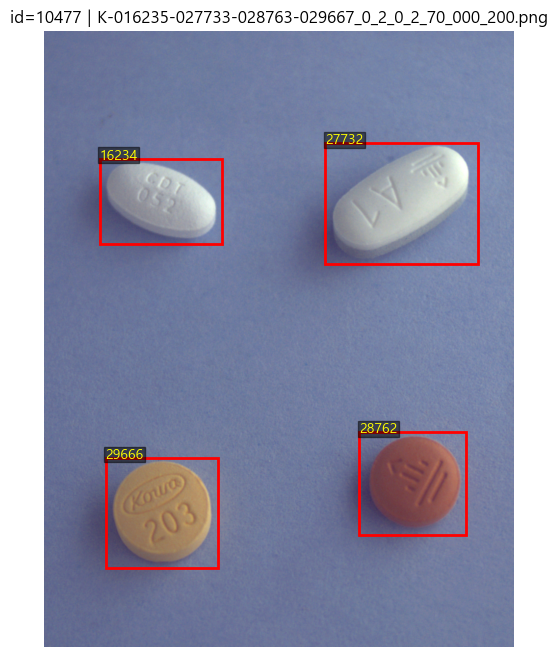

In [9]:
# =========================
# (유틸) file_name -> 실제 이미지 경로 resolve
# pill_preprocess_v3_robust.resolve_image_path에 image_index 지원을 추가했으므로
#           노트북 자체 함수는 얇은 래퍼로 대체
# =========================

def resolve_train_image_path(train_img_dir, file_name):
    """Cell 5에서 만든 IMAGE_INDEX를 활용하여 이미지 경로를 찾습니다."""
    yolo_img_dir = None
    try:
        yolo_img_dir = str(Path(getattr(cfg, "yolo_dataset_dir", "")) / "images")
    except Exception:
        pass
    return resolve_image_path(
        train_img_dir, file_name,
        image_index=globals().get("IMAGE_INDEX"),
        yolo_img_dir=yolo_img_dir,
    )

def plot_image_with_bboxes(cfg, coco, image_id, max_show=50):
    img = next((im for im in coco["images"] if im["id"] == image_id), None)
    if img is None:
        print("image not found:", image_id); return

    path = resolve_train_image_path(cfg.train_img_dir, img["file_name"])
    if path is None:
        print("image file missing:", img["file_name"]); return

    imarr = mpimg.imread(str(path))

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(imarr)
    ax.set_title(f"id={image_id} | {Path(img['file_name']).name}")
    ax.axis("off")

    anns = [a for a in coco["annotations"] if a["image_id"] == image_id][:max_show]
    for a in anns:
        x, y, w, h = a["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, str(a["category_id"]), color="yellow", fontsize=10,
                bbox=dict(facecolor="black", alpha=0.5, pad=1))
    plt.show()

# 랜덤 1장 확인
rand_img_id = random.choice([im["id"] for im in coco["images"]])
plot_image_with_bboxes(cfg, coco, rand_img_id)


## 3) Train / Val 분리

- `cfg.val_ratio` 비율로 이미지 단위 랜덤 분할합니다.


In [10]:
# =========================
# 2) Train / Val 분리
# =========================
# 이중할당(val_ratio = val_ratio=...) 및 중첩 getattr 제거 → 단순 참조
val_ratio = float(cfg.val_ratio)
train_coco, val_coco = split_coco_by_image(coco, val_ratio=val_ratio, seed=cfg.seed)
print("train images:", len(train_coco["images"]), "train anns:", len(train_coco["annotations"]))
print("val images:", len(val_coco["images"]), "val anns:", len(val_coco["annotations"]))


train images: 10998 train anns: 41777
val images: 1221 val anns: 4676


## 4) YOLO 데이터셋 export

- GCI의 `global_index`를 YOLO class로 사용하여 `images/` + `labels/` + `dataset.yaml`을 생성합니다.
- 클래스 불균형 보정이 활성화되어 있으면 `train.txt`에 가중치 기반 오버샘플링을 적용합니다.


In [11]:
# =========================
# 3) category_id <-> yolo cls 매핑 (py 기준: GCI(global_index) 직접 사용)
# - yolo cls = global_index (0..K-1)
# - category_id = 원본 category_id (train57 기준)
# =========================

# gci_json_path는 1.5 셀에서 생성/로드됩니다.
gci_json_path = getattr(cfg, "gci_json_path", "")
if not gci_json_path or not Path(gci_json_path).exists():
    # 혹시 cfg.gci_train57_path만 있는 케이스
    if getattr(cfg, "gci_train57_path", "") and Path(cfg.gci_train57_path).exists():
        gci_json_path = cfg.gci_train57_path

with open(gci_json_path, "r", encoding="utf-8") as f:
    gci = json.load(f)

id_to_index = {int(k): int(v) for k, v in (gci.get("id_to_index") or {}).items()}
index_to_id = {int(k): int(v) for k, v in (gci.get("index_to_id") or {}).items()}

# mapping
catid_to_yolo = dict(id_to_index)  # category_id -> global_index
yolo_to_catid = {v: k for k, v in id_to_index.items()}

# class names (global_index 순서)
cat_map = gci.get("category_map") or {}
K = len(index_to_id)
names = []
for i in range(K):
    cid = index_to_id[i]
    info = cat_map.get(str(cid), {})
    names.append(info.get("category_name") or str(cid))

print("[MAP] K:", K)
print("[MAP] example 0..5:", [(i, index_to_id[i], names[i]) for i in range(min(6, K))])


# -------------------------
# (추가) local_categories.csv 유틸리티 + (옵션) train subset 매핑
# - 일부 셀(4.5, 8)이 local_categories.csv / SUBMIT_INDEX_TO_ID 를 참조합니다.
# - Jupyter/VSCode에서 "확인되지 않은 참조" 경고가 뜨지 않도록 여기서 정의합니다.
# -------------------------

# 기본값(사용하지 않더라도 NameError 방지)
SUBMIT_INDEX_TO_ID: dict[int, int] = {}
ID_TO_SUBMIT_INDEX: dict[int, int] = {}

def _infer_category_name_map(train_coco: dict) -> dict[int, str]:
    m = {}
    for cat in (train_coco.get("categories") or []):
        try:
            cid = int(cat.get("id"))
        except Exception:
            continue
        name = cat.get("name") or cat.get("category_name") or str(cid)
        m[cid] = str(name)
    return m

def _used_category_ids(train_coco: dict) -> list[int]:
    used = set()
    for ann in (train_coco.get("annotations") or []):
        if "category_id" in ann:
            try:
                used.add(int(ann["category_id"]))
            except Exception:
                pass
    return sorted(used)

def _sort_catids_by_gci(cat_ids: list[int], id_to_index: dict[int, int]) -> list[int]:
    if not id_to_index:
        return sorted(cat_ids)
    return sorted(cat_ids, key=lambda cid: (id_to_index.get(int(cid), 10**9), int(cid)))

def _ensure_and_load_local_categories(cfg, train_coco: dict, yolo_dir: str, verbose=True):
    '''
    local_categories.csv를 (필요 시) 생성/동기화하고 로드합니다.

    출력 CSV 컬럼:
      - yolo_cls: 모델이 출력하는 class index
      - category_id: 원본 category_id
      - global_index: (가능하면) GCI의 global index
      - category_name: (가능하면) train_coco 또는 GCI에서 유추한 이름
    '''
    yolo_dir = Path(yolo_dir)
    yolo_dir.mkdir(parents=True, exist_ok=True)
    local_csv = yolo_dir / "local_categories.csv"

    name_map = _infer_category_name_map(train_coco)
    used_cat_ids = _used_category_ids(train_coco)

    # GCI 사용 가능 여부
    has_gci = bool(id_to_index) and bool(index_to_id)
    use_subset = bool(getattr(cfg, "gci_use_train_subset", False))

    rows = []
    if use_subset:
        # subset: 학습에 등장한 category_id만 골라 nc를 줄이는 케이스
        ordered = _sort_catids_by_gci(used_cat_ids, id_to_index if has_gci else {})
        global SUBMIT_INDEX_TO_ID, ID_TO_SUBMIT_INDEX
        SUBMIT_INDEX_TO_ID = {i: int(cid) for i, cid in enumerate(ordered)}
        ID_TO_SUBMIT_INDEX = {int(cid): int(i) for i, cid in enumerate(ordered)}

        for local_idx, cid in SUBMIT_INDEX_TO_ID.items():
            gidx = int(id_to_index[cid]) if has_gci and cid in id_to_index else None
            cname = name_map.get(cid) or (names[gidx] if (gidx is not None and gidx < len(names)) else str(cid))
            rows.append({
                "yolo_cls": int(local_idx),
                "category_id": int(cid),
                "global_index": (int(gidx) if gidx is not None else ""),
                "category_name": str(cname),
            })
    else:
        # 기본: yolo cls = global_index (GCI 기준) 또는 (GCI가 없다면) 등장 cat_id를 순차 인덱싱
        if has_gci:
            for gidx in range(len(index_to_id)):
                cid = int(index_to_id[gidx])
                cname = name_map.get(cid) or (names[gidx] if gidx < len(names) else str(cid))
                rows.append({
                    "yolo_cls": int(gidx),
                    "category_id": int(cid),
                    "global_index": int(gidx),
                    "category_name": str(cname),
                })
        else:
            ordered = sorted(used_cat_ids)
            for local_idx, cid in enumerate(ordered):
                rows.append({
                    "yolo_cls": int(local_idx),
                    "category_id": int(cid),
                    "global_index": "",
                    "category_name": str(name_map.get(cid) or cid),
                })

    df_new = pd.DataFrame(rows)

    # 기존 파일이 있으면 비교 후 동기화
    if local_csv.exists():
        try:
            df_old = pd.read_csv(local_csv)
            key_cols = ["yolo_cls", "category_id"]
            ok = all(col in df_old.columns for col in key_cols)
            if ok:
                same = df_old[key_cols].astype(int).equals(df_new[key_cols].astype(int))
            else:
                same = False
        except Exception:
            same = False

        if not same:
            df_new.to_csv(local_csv, index=False, encoding="utf-8-sig")
            if verbose:
                print("[local_categories] 업데이트:", local_csv, "| rows:", len(df_new))
        else:
            if verbose:
                print("[local_categories] 기존 파일 사용:", local_csv, "| rows:", len(df_old))
            df_new = df_old
    else:
        df_new.to_csv(local_csv, index=False, encoding="utf-8-sig")
        if verbose:
            print("[local_categories] 생성:", local_csv, "| rows:", len(df_new))

    return df_new, local_csv

# 외부에서 호출할 수 있도록 alias 제공
def ensure_and_load_local_categories(cfg, train_coco: dict, yolo_dir: str, verbose=True):
    return _ensure_and_load_local_categories(cfg, train_coco, yolo_dir, verbose=verbose)


[MAP] K: 118
[MAP] example 0..5: [(0, 249, '마그밀정(수산화마그네슘)'), (1, 572, '게보린정 300mg/PTP'), (2, 1865, '알마겔정(알마게이트)(수출명:유한가스트라겔정)'), (3, 1899, '보령부스파정 5mg'), (4, 2482, '뮤테란캡슐 100mg'), (5, 3350, '일양하이트린정 2mg')]


In [12]:
# =========================
# 4) YOLO 학습용 데이터셋 내보내기 (py 기준: 이미지 root 재귀 인덱스 사용)
#   - out_root/images, out_root/labels 생성
#   - file_name(베이스명) 기준으로 원본 이미지에서 copy
#   - 라벨은 yolo cls = global_index 로 저장
# =========================

def export_yolo_dataset_indexed(train_img_root, image_index, train_coco, val_coco, catid_to_yolo, out_root):
    out_root = Path(out_root)
    images_dir = out_root / "images"
    labels_dir = out_root / "labels"
    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)

    def _ann_by_img(coco):
        d = defaultdict(list)
        for a in coco.get("annotations", []):
            d[a["image_id"]].append(a)
        return d

    def _export_split(coco_split):
        rels = []
        ann_map = _ann_by_img(coco_split)

        missing = 0
        for im in coco_split.get("images", []):
            fn = Path(im["file_name"]).name

            src = resolve_train_image_path(train_img_root, fn)
            if src is None:
                # 원본 root 밖에 있더라도 image_index에 있으면 resolve가 잡아줍니다.
                missing += 1
                continue

            dst = images_dir / fn
            if not dst.exists():
                shutil.copy2(src, dst)

            # label write
            W = float(im.get("width", getattr(cfg, "image_width", 976)))
            H = float(im.get("height", getattr(cfg, "image_height", 1280)))
            label_path = labels_dir / (Path(fn).stem + ".txt")

            lines = []
            for a in ann_map.get(im["id"], []):
                cid = int(a.get("category_id", -1))
                cls = catid_to_yolo.get(cid, None)
                if cls is None:
                    continue
                x, y, w, h = map(float, a["bbox"])
                cx = (x + w / 2.0) / W
                cy = (y + h / 2.0) / H
                nw = w / W
                nh = h / H

                # clamp
                cx = min(1.0, max(0.0, cx))
                cy = min(1.0, max(0.0, cy))
                nw = min(1.0, max(0.0, nw))
                nh = min(1.0, max(0.0, nh))

                lines.append(f"{int(cls)} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

            with open(label_path, "w", encoding="utf-8") as f:
                f.write("\n".join(lines) + ("\n" if lines else ""))

            rels.append(str(Path("images") / fn))

        if missing:
            print(f"[EXPORT] missing images in split: {missing}")
        return rels

    train_rel = _export_split(train_coco)
    val_rel   = _export_split(val_coco)
    return train_rel, val_rel


out_root = cfg.yolo_dataset_dir

train_rel, val_rel = export_yolo_dataset_indexed(
    cfg.train_img_dir,
    globals().get("IMAGE_INDEX", {}),
    train_coco,
    val_coco,
    catid_to_yolo,
    out_root
)

# (선택) 클래스 불균형 보정: train.txt에 "추가 샘플"을 append
if getattr(cfg, "balance_enable", False) and float(getattr(cfg, "balance_extra_ratio", 0.0)) > 0:
    class_w = get_balance_class_weights(cfg, train_coco, nc=len(names))
    print_class_balance_report(train_coco, class_w, topk=10)

    train_list = make_weighted_train_list(
        train_rel,
        train_coco,
        class_w,
        extra_ratio=float(getattr(cfg, "balance_extra_ratio", 0.0)),
        seed=int(getattr(cfg, "seed", 42)),
        power=float(getattr(cfg, "balance_power", 1.0)),
    )
else:
    train_list = train_rel

# Ultralytics는 train/val에 txt list도 받을 수 있으므로, 교차플랫폼 & oversample에 유리합니다.
train_txt = write_split_list(out_root, "train", train_list)
val_txt   = write_split_list(out_root, "val",   val_rel)

data_yaml = str(Path(out_root) / "dataset.yaml")
write_dataset_yaml(
    out_root,
    names,
    data_yaml,
    train=Path(train_txt).name,
    val=Path(val_txt).name,
)

print("out_root:", out_root)
print("data_yaml:", data_yaml)
print("train_txt lines:", len(train_list), "| val_txt lines:", len(val_rel))


[class_weight] using COCO-balanced weights
[class_balance] n_classes=118 | n_ann=41777
[class_balance] top by ann count: [(16550, 1214), (16547, 1204), (16231, 745), (16261, 742), (20237, 591), (11219, 578), (15709, 578), (35205, 569), (16234, 566), (3613, 561)]
[class_balance] top weights (cid, weight, count): [(16550, 0.292, 1214), (16547, 0.294, 1204), (16231, 0.475, 745), (16261, 0.477, 742), (20237, 0.599, 591), (11219, 0.613, 578), (15709, 0.613, 578), (35205, 0.622, 569), (16234, 0.626, 566), (3613, 0.631, 561)]
out_root: yolo_pill_ds
data_yaml: yolo_pill_ds\dataset.yaml
train_txt lines: 14297 | val_txt lines: 1221


## 4.5) GCI 라벨 치환 (호환)

- 과거에 로컬 인덱스(0..K-1)로 export된 라벨을 GCI `global_index`로 치환할 때 사용합니다.
- 이미 GCI 모드로 export했다면 `cfg.force_apply_gci_remap = False` (기본값)로 생략됩니다.


In [13]:
# =========================
# 4.5) (호환) apply_gci_to_yolo.py 로직 통합
# - 로컬 YOLO 인덱스(0..K-1)로 export된 labels를 GCI global_index로 치환
# - GCI 전체 names를 포함한 dataset_gci.yaml 생성
# =========================
from shutil import copy2

def _load_gci(gci_json_path: str):
    gci_json_path = Path(gci_json_path)
    with open(gci_json_path, "r", encoding="utf-8") as f:
        gci = json.load(f)

    id_to_index = {int(k): int(v) for k, v in gci["id_to_index"].items()}
    index_to_id = {int(k): int(v) for k, v in gci["index_to_id"].items()}

    raw_cat_map = gci.get("category_map", {})
    category_map = {int(k): v for k, v in raw_cat_map.items()}
    total_categories = int(gci["metadata"]["total_categories"])

    return id_to_index, index_to_id, category_map, total_categories

# NOTE: local_categories.csv 유틸리티는 3) 셀에서 정의한 ensure_and_load_local_categories()를 사용합니다.


def _build_local_idx_to_catid(local_categories_csv: str):
    df = pd.read_csv(local_categories_csv)
    if "category_id" not in df.columns:
        raise ValueError("local_categories_csv에 'category_id' 컬럼이 없습니다.")
    local_idx_to_catid = {int(i): int(row["category_id"]) for i, row in df.iterrows()}
    return local_idx_to_catid, df

def _remap_labels_to_global(labels_dir: str, local_idx_to_global_idx: dict):
    labels_dir = Path(labels_dir)
    txt_files = list(labels_dir.rglob("*.txt"))
    if not txt_files:
        print(f"[WARN] 라벨 txt가 없습니다: {labels_dir}")
        return 0

    changed = 0
    for txt_path in tqdm(txt_files, desc="Remapping labels", leave=False):
        lines = txt_path.read_text(encoding="utf-8").strip().splitlines()
        if len(lines) == 1 and lines[0] == "":
            continue

        lines_out = []
        modified = False
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                lines_out.append(line)
                continue

            local_cls = int(float(parts[0]))
            if local_cls not in local_idx_to_global_idx:
                raise ValueError(f"[ERROR] {txt_path}에서 local class {local_cls}를 매핑할 수 없습니다.")

            global_cls = int(local_idx_to_global_idx[local_cls])
            if global_cls != local_cls:
                modified = True
            parts[0] = str(global_cls)
            lines_out.append(" ".join(parts))

        if modified:
            txt_path.write_text("\n".join(lines_out) + "\n", encoding="utf-8")
            changed += 1

    return changed

def _write_gci_yaml(
    output_yaml_path: str,
    dataset_root: str,
    train_rel: str,
    val_rel: str,
    total_categories: int,
    index_to_id: dict,
    category_map: dict,
):
    output_yaml_path = Path(output_yaml_path)
    dataset_root = str(Path(dataset_root))

    lines = []
    lines.append(f"path: {dataset_root}")
    lines.append(f"train: {train_rel}")
    lines.append(f"val: {val_rel}")
    lines.append("")
    lines.append(f"nc: {total_categories}")
    lines.append("names:")

    for idx in range(total_categories):
        cat_id = index_to_id.get(idx)
        if cat_id is None:
            name = "Unknown"
        else:
            name = category_map.get(cat_id, {}).get("category_name", "Unknown")
            name = str(name).replace("'", "''")
        lines.append(f"  {idx}: '{name}'")

    output_yaml_path.write_text("\n".join(lines) + "\n", encoding="utf-8-sig")
    return str(output_yaml_path)

# ---- 실행부 ----
cfg.force_apply_gci_remap = bool(getattr(cfg, "force_apply_gci_remap", False))
gci_path = Path(getattr(cfg, "gci_json_path", ""))

yolo_dir = Path(getattr(cfg, "yolo_dataset_dir", "yolo_dataset"))
labels_dir = yolo_dir / "labels"

# export 단계에서 만들어진 train/val txt를 우선 사용 (없으면 images/로 fallback)
train_ref = Path("train.txt") if (yolo_dir / "train.txt").exists() else Path("images")
val_ref   = Path("val.txt")   if (yolo_dir / "val.txt").exists()   else Path("images")

if not gci_path.exists():
    print("[GCI APPLY] skip: gci_json_path not found ->", gci_path)
else:
    id_to_index, index_to_id, category_map, total_categories = _load_gci(str(gci_path))
    # local_categories.csv를 '확정'한 뒤(생성/동기화) 반드시 그 파일을 로드해서 사용
    local_df, local_csv = ensure_and_load_local_categories(cfg, train_coco, str(yolo_dir), verbose=True)
    print("[GCI APPLY] local_categories.csv 사용:", local_csv, "| rows:", len(local_df))

    # 라벨 치환은 '로컬로 export된 데이터셋을 GCI로 바꾸고 싶을 때'만 수행
    if cfg.force_apply_gci_remap:
        local_idx_to_catid, _ = _build_local_idx_to_catid(str(local_csv))

        # 로컬 idx -> 전역 idx
        local_idx_to_global_idx = {}
        for local_idx, cat_id in local_idx_to_catid.items():
            if cat_id not in id_to_index:
                raise ValueError(f"[ERROR] category_id={cat_id}가 GCI에 없습니다. (local_idx={local_idx})")
            local_idx_to_global_idx[local_idx] = id_to_index[cat_id]

        changed_files = _remap_labels_to_global(str(labels_dir), local_idx_to_global_idx)
        print(f"[GCI APPLY] 수정된 라벨 파일 수: {changed_files:,} / labels 총 파일 수: {len(list(labels_dir.rglob('*.txt'))):,}")
    else:
        print("[GCI APPLY] 라벨 치환은 생략합니다. (cfg.force_apply_gci_remap=False)")

    # export 단계에서 USE_GCI가 True였다면 라벨은 이미 global_index입니다.
    export_used_gci = bool(globals().get("USE_GCI", False))

    if cfg.force_apply_gci_remap or export_used_gci:
        # (요청) train split subset을 쓰는 경우, nc/names도 subset으로 YAML 생성
        use_subset = bool(getattr(cfg, "gci_use_train_subset", False)) and ("SUBMIT_INDEX_TO_ID" in globals())

        if use_subset:
            subset_index_to_id = {int(k): int(v) for k, v in SUBMIT_INDEX_TO_ID.items()}
            subset_total = len(subset_index_to_id)

            out_yaml = yolo_dir / "dataset_gci_train_subset.yaml"
            saved_yaml = _write_gci_yaml(
                output_yaml_path=str(out_yaml),
                dataset_root=str(yolo_dir),
                train_rel=str(train_ref),
                val_rel=str(val_ref),
                total_categories=subset_total,
                index_to_id=subset_index_to_id,
                category_map=category_map,
            )
            print("[GCI APPLY] dataset_gci_train_subset.yaml 생성:", saved_yaml)
            print("[GCI APPLY] nc =", subset_total, "| index_range:", f"0-{subset_total-1}")
            print("[GCI APPLY] (권장) 학습/평가에는 dataset.yaml(=subset) 또는 dataset_gci_train_subset.yaml을 사용하세요.")

        else:
            # (기본) 전역 GCI YAML 생성 (labels가 global index라는 전제)
            out_yaml = yolo_dir / "dataset_gci.yaml"
            saved_yaml = _write_gci_yaml(
                output_yaml_path=str(out_yaml),
                dataset_root=str(yolo_dir),
                train_rel=str(train_ref),
                val_rel=str(val_ref),
                total_categories=total_categories,
                index_to_id=index_to_id,
                category_map=category_map,
            )
            print("[GCI APPLY] dataset_gci.yaml 생성:", saved_yaml)
            print("[GCI APPLY] nc =", total_categories, "| index_range:", f"0-{total_categories-1}")
            if cfg.force_apply_gci_remap:
                print("[GCI APPLY] 이제 학습/평가에는 dataset_gci.yaml을 쓰는 것을 권장합니다.")
            else:
                print("[GCI APPLY] (skip) export가 로컬 인덱스였고, 라벨 치환도 하지 않았습니다.")
                print("          -> 현재 dataset.yaml을 그대로 사용하세요.")


[local_categories] 기존 파일 사용: yolo_pill_ds\local_categories.csv | rows: 118
[GCI APPLY] local_categories.csv 사용: yolo_pill_ds\local_categories.csv | rows: 118
[GCI APPLY] 라벨 치환은 생략합니다. (cfg.force_apply_gci_remap=False)


## 5) 베이스라인 학습 (옵션)

- Optuna 전에 데이터/파이프라인이 정상인지 빠르게 확인하는 용도입니다.
- `RUN_BASELINE = True`로 변경하면 실행됩니다.


In [14]:
# =========================
# 5) 베이스라인 학습 (옵션)
# - 학습 중 중단 버튼(■)을 누르면 현재 epoch를 마친 뒤 안전하게 종료합니다.
# =========================

RUN_BASELINE = False  # ✅ 필요할 때만 True로 바꿔 실행하세요.

if RUN_BASELINE:
    model = build_yolo_model(cfg.base_model)

    stopper = GracefulStopper().attach(model)

    baseline = train_yolo(
        model,
        data_yaml=data_yaml,
        cfg=cfg,
        epochs=5,
        project=cfg.work_dir,
        name=cfg.baseline_name,
        exist_ok=True,
        batch=-1,
        amp=True,
        workers=int(getattr(cfg, "workers", 0)),
    )

    stopper.detach()

    if stopper.stopped:
        info = stopper.summary
        print(f"\n⚠️ 학습이 epoch {info.get('epoch','?')}/{info.get('epochs','?')}에서 중단되었습니다.")
        print(f"   저장 경로: {info.get('save_dir','?')}")
        print("   → best.pt가 저장되어 있으면 이후 셀에서 사용할 수 있습니다.")


### (옵션) 여러 YOLO 모델 비교

- `cfg.model_candidates`에 있는 각 모델을 한 번씩 학습합니다. 필요할 때만 주석 해제하세요.


In [15]:
# 여러 모델 후보를 한 번씩 학습해보고 싶을 때 사용
# results = []
# for mname in getattr(cfg, 'model_candidates', [cfg.base_model]):
#     print('\n' + '='*80)
#     print('MODEL:', mname)
#     print('='*80)
#     m = build_yolo_model(mname)
#     r = train_yolo(
#         m,
#         data_yaml=data_yaml,
#         cfg=cfg,
#         epochs=cfg.epochs,
#         project=cfg.work_dir,
#         name=f"{cfg.baseline_name}_{Path(mname).stem}",
#         exist_ok=True,
#     )
#     results.append((mname, r))
# results


## 6) Validation 평가 (COCOeval)

- Val split을 COCO JSON으로 저장하고, YOLO 추론 결과와 비교하여 mAP@\[0.75:0.95\]를 계산합니다.


In [16]:
# =========================
# 6) val GT COCO 저장 (평가에서 사용할 파일)
# - pill_preprocess.save_coco_json은 parent dir를 자동 생성합니다.
# =========================

val_gt_path = save_coco_json(val_coco, Path(cfg.export_dir)/"val_gt.json")
val_gt_path

'exports_pill\\val_gt.json'

In [17]:
# =========================
# (진단) 학습 결과(best.pt) 저장 위치 확인
# - Windows/Mac 혼용 환경에서도 동일하게 확인 가능
# =========================

def _print_tree(root, max_depth=3):
    root = Path(root)
    if not root.exists():
        print(f"[X] not found: {root}")
        return
    print(f"[OK] {root.resolve()}")
    base_depth = len(root.parts)
    for p in sorted(root.rglob("*")):
        depth = len(p.parts) - base_depth
        if depth > max_depth:
            continue
        prefix = "  " * depth
        if p.is_dir():
            print(f"{prefix}📁 {p.name}")
        else:
            print(f"{prefix}📄 {p.name}")

print("CWD:", Path().resolve())
print("cfg.work_dir:", cfg.work_dir)
_print_tree(cfg.work_dir, max_depth=4)

# best/last 후보를 한 번에 스캔
patterns = [
    str(Path(cfg.work_dir)/"**"/"weights"/"best.pt"),
    str(Path(cfg.work_dir)/"**"/"weights"/"last.pt"),
    str(Path("runs")/"**"/"weights"/"best.pt"),
    str(Path("runs")/"**"/"weights"/"last.pt"),
]
hits = []
for pat in patterns:
    hits += glob.glob(pat, recursive=True)
hits = [p for p in hits if Path(p).is_file()]
hits = sorted(hits, key=lambda p: Path(p).stat().st_mtime, reverse=True)

print("\n[FOUND WEIGHTS]")
if not hits:
    print("  - weights 파일을 찾지 못했습니다. (베이스라인 학습 셀부터 실행해 주세요)")
else:
    for p in hits[:20]:
        print("  -", p)


CWD: C:\Users\LEETAEHO\Desktop\AI_07_basic
cfg.work_dir: yolo_runs
[OK] C:\Users\LEETAEHO\Desktop\AI_07_basic\yolo_runs
  📁 final

[FOUND WEIGHTS]
  - runs\detect\yolo_runs\final\pill_baseline_augdata_final_retrain\weights\last.pt
  - runs\detect\yolo_runs\final\pill_baseline_augdata_final_retrain\weights\best.pt
  - runs\detect\yolo_runs\final\pill_baseline_augdata_final_from_optuna_best\weights\best.pt
  - runs\detect\yolo_runs\final\pill_baseline_augdata_final_from_optuna_best\weights\last.pt
  - runs\detect\yolo_runs\optuna\trial_029_yolov9c_bs16\weights\best.pt
  - runs\detect\yolo_runs\optuna\trial_029_yolov9c_bs16\weights\last.pt
  - runs\detect\yolo_runs\optuna\trial_028_yolov9c_bs16\weights\last.pt
  - runs\detect\yolo_runs\optuna\trial_028_yolov9c_bs16\weights\best.pt
  - runs\detect\yolo_runs\optuna\trial_026_yolov9c_bs16\weights\best.pt
  - runs\detect\yolo_runs\optuna\trial_026_yolov9c_bs16\weights\last.pt
  - runs\detect\yolo_runs\optuna\trial_025_yolov9c_bs16\weights\las

In [18]:
# =========================
# (평가 준비) best.pt 경로를 "학습 결과 save_dir"에서 안전하게 가져오기
# - Ultralytics는 baseline, baseline2 처럼 이름을 바꿔 저장할 수 있어 고정 경로 가정이 깨질 수 있습니다.
# - 또한 project/name을 주지 않으면 기본 runs/detect/... 아래로 저장됩니다.
# =========================


def resolve_best_pt(*roots, preferred_name="baseline"):
    # roots: 검색할 루트 폴더들 (예: cfg.work_dir, "runs", "runs/detect")
    roots = [str(r) for r in roots if r is not None]
    # 중복 제거
    seen = set()
    roots = [r for r in roots if not (r in seen or seen.add(r))]

    patterns = []
    for root in roots:
        patterns += [
            str(Path(root) / f"{preferred_name}*" / "weights" / "best.pt"),
            str(Path(root) / "**" / "weights" / "best.pt"),
            str(Path(root) / "**" / "best.pt"),
        ]

    cand = []
    for pat in patterns:
        cand += glob.glob(pat, recursive=True)

    # 존재하는 파일만
    cand = [p for p in cand if Path(p).is_file()]

    if not cand:
        return None

    cand = sorted(cand, key=lambda p: Path(p).stat().st_mtime, reverse=True)
    return Path(cand[0])

# ✅ work_dir 우선, 그다음 Ultralytics 기본 runs 경로까지 fallback
best_pt = resolve_best_pt(
    cfg.work_dir,
    "runs",
    Path("runs")/"detect",
    preferred_name=getattr(cfg, "baseline_name", "baseline"),
)

if best_pt is None or (not best_pt.exists()):
    raise FileNotFoundError(
        "best.pt를 찾지 못했습니다. 아래 진단 셀을 먼저 실행해 주세요.\n"
        f"- cfg.work_dir='{cfg.work_dir}'\n"
        "- (가능성 1) 베이스라인 학습 셀을 아직 실행하지 않음\n"
        "- (가능성 2) 학습이 중간에 실패/중단되어 weights가 저장되지 않음\n"
        "- (가능성 3) project/name이 적용되지 않아 runs/detect/... 에 저장됨"
    )

print("✅ best.pt:", best_pt)
best_model = YOLO(str(best_pt))


✅ best.pt: runs\detect\yolo_runs\final\pill_baseline_augdata_final_retrain\weights\best.pt


## 7) Optuna 하이퍼파라미터 탐색

**탐색 대상:** model, batch, lr0, weight_decay, degrees, translate, scale, mosaic

**Optuna 서브셋 모드:** 전체 데이터로 탐색하면 시간이 오래 걸릴 때 사용합니다.
- `cfg.optuna_use_subset = True` → 서브셋으로 빠르게 탐색
- **방법 1:** `cfg.optuna_ann_dirs`에 폴더 경로를 지정
- **방법 2:** 폴더 미지정 시 전체 데이터에서 `cfg.optuna_sample_ratio` 비율만큼 랜덤 샘플링

**배치 사이즈:** `cfg.optuna_batch_sizes`에서 후보를 설정합니다 (기본값: \[16, 32\]).

> 최종 재학습(7-1)은 항상 **전체 데이터**를 사용합니다.


## 7-ALT) Optuna 건너뛰기 — 3가지 모드

Optuna 탐색(7-0 ~ 7)을 건너뛰고 싶을 때, 또는 기존 학습을 이어서 하고 싶을 때 사용합니다.

| MODE | 설명 | 다음 셀 |
|------|------|--------|
| `"train"` | 수동 파라미터로 처음부터 최종 학습 | → 7-1 → 8 |
| `"resume"` | 기존 가중치(last.pt)에서 이어서 추가 학습 | → 7-1 → 8 |
| `"infer_only"` | 이미 학습된 best.pt로 바로 추론 | → 8 |


In [19]:
# =========================
# 7-ALT) Optuna 건너뛰기 — 3가지 모드
#   MODE = "train"      → 수동 파라미터로 처음부터 최종 학습
#   MODE = "resume"     → 기존 가중치에서 이어서 추가 학습
#   MODE = "infer_only" → 기존 best.pt로 바로 8) 추론
# =========================

# ─────────────────────────────────────────────────
# ✅ 모드 선택
# ─────────────────────────────────────────────────
MODE = "resume"  # "train", "resume", "infer_only"

# ─────────────────────────────────────────────────
# ✅ [train / resume 공통] 하이퍼파라미터
#    Optuna 결과를 복붙하거나, 원하는 값을 직접 지정하세요.
#    비워두면({}) cfg 기본값을 사용합니다.
# ─────────────────────────────────────────────────
MANUAL_BEST_PARAMS = {
    'model': 'yolov9c.pt',
    'batch': 16,
    'lr0': 0.0006842210774503367,
    'weight_decay': 6.950968174729179e-06,
    'degrees': 0.09518533777756984,
    'translate': 0.026433655431405134,
    'scale': 0.08019732047334832,
    'mosaic': 0.32782953163112527
}

# ─────────────────────────────────────────────────
# ✅ [resume] 이어서 학습할 가중치 경로
#    last.pt 권장 (학습 상태 포함), best.pt도 가능
#    비워두면 자동으로 가장 최근 last.pt를 탐색합니다.
# ─────────────────────────────────────────────────
RESUME_WEIGHTS = "runs/detect/yolo_runs/final/pill_baseline_augdata_final_retrain/weights/last.pt"  # 예: r"runs\detect\yolo_runs\final\...\weights\last.pt"

# ✅ [resume] 추가 학습 에폭 수 (기존 + 이 값만큼 더 학습)
RESUME_EXTRA_EPOCHS = 100

# ─────────────────────────────────────────────────
# ✅ [infer_only] 추론에 사용할 가중치 경로
#    비워두면 자동으로 가장 최근 best.pt를 탐색합니다.
# ─────────────────────────────────────────────────
MANUAL_WEIGHTS = "runs/detect/yolo_runs/final/pill_baseline_augdata_final_from_optuna_best/weights/best.pt"
# 예: r"runs\detect\yolo_runs\final\...\weights\best.pt"

# ═══════════════════════════════════════════════════
# 아래는 자동 처리
# ═══════════════════════════════════════════════════

def _find_weights(pattern="best.pt"):
    all_hits = []
    for d in [getattr(cfg, "project", "yolo_runs"), getattr(cfg, "work_dir", ""), "runs"]:
        if not d: continue
        all_hits.extend(glob.glob(str(Path(d) / "**" / "weights" / pattern), recursive=True))
    if all_hits:
        all_hits.sort(key=lambda p: Path(p).stat().st_mtime, reverse=True)
    return all_hits

if MODE == "train":
    RESUME_FROM = None
    print("🔧 [7-ALT] train 모드: 처음부터 최종 학습")
    if MANUAL_BEST_PARAMS:
        print(f"   params = {MANUAL_BEST_PARAMS}")
    else:
        print("   params = (비어있음 → cfg 기본값)")
    print("   → 다음으로 7-1 셀을 실행하세요.")

elif MODE == "resume":
    if RESUME_WEIGHTS and Path(RESUME_WEIGHTS).exists():
        RESUME_FROM = str(RESUME_WEIGHTS)
        print(f"🔄 [7-ALT] resume 모드: 수동 지정 가중치에서 이어서 학습")
    else:
        # 자동 탐색: 가장 최근 last.pt
        hits = _find_weights("last.pt")
        if hits:
            RESUME_FROM = hits[0]
            print(f"🔄 [7-ALT] resume 모드: 자동 탐색 가중치 (최신 last.pt)")
        else:
            # last.pt 없으면 best.pt로 fallback
            hits = _find_weights("best.pt")
            if hits:
                RESUME_FROM = hits[0]
                print(f"🔄 [7-ALT] resume 모드: last.pt 없음 → best.pt 사용")
            else:
                RESUME_FROM = None
                print("❌ 이어서 학습할 가중치를 찾을 수 없습니다.")
                print("   → RESUME_WEIGHTS에 경로를 직접 입력하세요.")
    if RESUME_FROM:
        print(f"   가중치: {RESUME_FROM}")
        print(f"   추가 에폭: +{RESUME_EXTRA_EPOCHS}")
        print("   → 다음으로 7-1 셀을 실행하세요.")

elif MODE == "infer_only":
    RESUME_FROM = None
    MANUAL_BEST_PARAMS = None
    if MANUAL_WEIGHTS and Path(MANUAL_WEIGHTS).exists():
        FINAL_WEIGHTS = Path(MANUAL_WEIGHTS)
        print(f"✅ [7-ALT] infer_only: 수동 지정 → {FINAL_WEIGHTS}")
    else:
        hits = _find_weights("best.pt")
        if hits:
            FINAL_WEIGHTS = Path(hits[0])
            print(f"✅ [7-ALT] infer_only: 자동 탐색 → {FINAL_WEIGHTS}")
            if len(hits) > 1:
                for i, p in enumerate(hits[:5]):
                    mtime = datetime.fromtimestamp(Path(p).stat().st_mtime)
                    marker = " ← 선택" if i == 0 else ""
                    print(f"   [{i}] {p}  ({mtime:%Y-%m-%d %H:%M}){marker}")
        else:
            FINAL_WEIGHTS = None
            print("❌ best.pt를 찾을 수 없습니다. MANUAL_WEIGHTS에 경로를 직접 입력하세요.")
    cfg.final_weights = str(FINAL_WEIGHTS) if FINAL_WEIGHTS else None
    print(f"\n🎯 FINAL_WEIGHTS = {cfg.final_weights}")
    print("   → 7-1 건너뛰고 바로 8) 추론으로 이동하세요.")

else:
    raise ValueError(f"MODE는 'train', 'resume', 'infer_only' 중 하나여야 합니다. 현재: {MODE}")


🔄 [7-ALT] resume 모드: 수동 지정 가중치에서 이어서 학습
   가중치: runs/detect/yolo_runs/final/pill_baseline_augdata_final_retrain/weights/last.pt
   추가 에폭: +100
   → 다음으로 7-1 셀을 실행하세요.


In [20]:
# =========================
# 7-0) Optuna용 서브셋 데이터셋 구축 (NEW)
# - cfg.optuna_use_subset=True 일 때만 실행
# - 방법 1: cfg.optuna_ann_dirs 지정 → 해당 폴더만으로 COCO 빌드
# - 방법 2: 폴더 미지정 → 전체 데이터에서 cfg.optuna_sample_ratio만큼 랜덤 샘플링
# - 결과: optuna_data_yaml (Optuna에서 사용), data_yaml (최종 재학습에서 사용)
# =========================

if bool(getattr(cfg, "optuna_use_subset", False)):

    _optuna_ann_dirs    = getattr(cfg, "optuna_ann_dirs", [])
    _optuna_image_roots = getattr(cfg, "optuna_image_roots", [])
    _optuna_sample_ratio = float(getattr(cfg, "optuna_sample_ratio", 0.1))

    # -------------------------------------------------------
    # 방법 1: 특정 폴더 지정
    # -------------------------------------------------------
    if _optuna_ann_dirs and any(Path(d).exists() for d in _optuna_ann_dirs):
        print("=" * 80)
        print("[OPTUNA SUBSET] 방법 1: 지정 폴더에서 서브셋 구축")
        print(f"  ann_dirs:    {_optuna_ann_dirs}")
        print(f"  image_roots: {_optuna_image_roots}")

        # 이미지 인덱스 (서브셋 폴더만)
        _opt_img_roots = [r for r in _optuna_image_roots if Path(r).exists()]
        if not _opt_img_roots:
            # 이미지 루트를 지정하지 않았으면 전체 IMAGE_INDEX 재활용
            _opt_img_index = IMAGE_INDEX
            print("  [INFO] optuna_image_roots 미지정 → 전체 IMAGE_INDEX 사용")
        else:
            _opt_img_index, _, _ = build_image_index(_opt_img_roots)
            print(f"  [IMG] optuna subset indexed: {len(_opt_img_index):,}")

        # JSON 수집 (서브셋 폴더만)
        _opt_json_paths = collect_json_paths(_optuna_ann_dirs)
        print(f"  [JSON] optuna subset json files: {len(_opt_json_paths):,}")

        # COCO 빌드 (Cell 5와 동일한 로직, 서브셋 데이터로)
        _opt_invalid = defaultdict(int)
        _opt_imgid_by_name = {}
        _opt_images = []
        _opt_annotations = []
        _opt_next_img_id = 1
        _opt_next_ann_id = 1
        _opt_seen_bbox = set()

        for jf in _opt_json_paths:
            try:
                with open(jf, "r", encoding="utf-8") as f:
                    data = json.load(f)
            except Exception:
                _opt_invalid["json_read_fail"] += 1
                continue

            img_meta = (data.get("images") or [{}])[0]
            ann_list = data.get("annotations") or []
            if not ann_list:
                continue

            ann = ann_list[0]
            fn_raw = img_meta.get("file_name") or ann.get("file_name") or data.get("file_name")
            if not fn_raw:
                continue
            file_name = Path(str(fn_raw)).name

            if bool(getattr(cfg, "exclude_index_images", True)) and ("_index" in file_name):
                continue

            bbox = ann.get("bbox", None)
            if not (isinstance(bbox, (list, tuple)) and len(bbox) == 4):
                continue
            try:
                bx, by, bw, bh = map(float, bbox)
            except Exception:
                continue
            if bw <= 0 or bh <= 0:
                continue

            W = float(img_meta.get("width", getattr(cfg, "image_width", 976)))
            H = float(img_meta.get("height", getattr(cfg, "image_height", 1280)))

            raw_id = img_meta.get("dl_idx", None)
            if raw_id is None or str(raw_id).strip() == "":
                raw_id = ann.get("category_id", None)
            if raw_id is None:
                continue

            cat_id, _ = normalize_category_id(raw_id, jf,
                shift_subdir=shift_subdir, shift_delta=shift_delta, apply_only=apply_only)
            if cat_id is None or int(cat_id) < 0:
                continue

            img_path = _opt_img_index.get(file_name) or IMAGE_INDEX.get(file_name)
            if not img_path or not Path(img_path).exists():
                continue

            key = (file_name, int(cat_id), round(bx, 3), round(by, 3), round(bw, 3), round(bh, 3))
            if key in _opt_seen_bbox:
                continue
            _opt_seen_bbox.add(key)

            if file_name not in _opt_imgid_by_name:
                _opt_imgid_by_name[file_name] = _opt_next_img_id
                _opt_images.append({
                    "id": _opt_next_img_id, "file_name": file_name,
                    "width": int(W), "height": int(H), "source_path": img_path,
                })
                _opt_next_img_id += 1

            _opt_annotations.append({
                "id": _opt_next_ann_id,
                "image_id": _opt_imgid_by_name[file_name],
                "category_id": int(cat_id),
                "bbox": [bx, by, bw, bh],
                "area": float(bw * bh),
                "iscrowd": 0,
            })
            _opt_next_ann_id += 1

        # categories는 전체 데이터와 동일하게 (nc 일관성 유지)
        optuna_coco = {"images": _opt_images, "annotations": _opt_annotations, "categories": list(coco["categories"])}

    # -------------------------------------------------------
    # 방법 2: 전체 데이터에서 랜덤 샘플링
    # -------------------------------------------------------
    else:
        print("=" * 80)
        print(f"[OPTUNA SUBSET] 방법 2: 전체 데이터에서 {_optuna_sample_ratio*100:.0f}% 랜덤 샘플링")

        _rng = random.Random(cfg.seed)
        all_img_ids = [im["id"] for im in coco["images"]]
        _rng.shuffle(all_img_ids)
        n_sample = max(1, int(len(all_img_ids) * _optuna_sample_ratio))
        sampled_ids = set(all_img_ids[:n_sample])

        _opt_images = [im for im in coco["images"] if im["id"] in sampled_ids]
        _opt_annotations = [a for a in coco["annotations"] if a["image_id"] in sampled_ids]
        optuna_coco = {"images": _opt_images, "annotations": _opt_annotations, "categories": list(coco["categories"])}

    # -------------------------------------------------------
    # 공통: train/val split → YOLO export → dataset_optuna.yaml
    # -------------------------------------------------------
    _opt_val_ratio = float(cfg.val_ratio)
    optuna_train_coco, optuna_val_coco = split_coco_by_image(optuna_coco, val_ratio=_opt_val_ratio, seed=cfg.seed)

    _opt_out_root = getattr(cfg, "optuna_dataset_dir", "yolo_pill_ds_optuna")

    optuna_train_rel, optuna_val_rel = export_yolo_dataset_indexed(
        cfg.train_img_dir,
        IMAGE_INDEX,
        optuna_train_coco,
        optuna_val_coco,
        catid_to_yolo,
        _opt_out_root,
    )

    optuna_train_txt = write_split_list(_opt_out_root, "train", optuna_train_rel)
    optuna_val_txt   = write_split_list(_opt_out_root, "val",   optuna_val_rel)

    optuna_data_yaml = str(Path(_opt_out_root) / "dataset.yaml")
    write_dataset_yaml(
        _opt_out_root,
        names,
        optuna_data_yaml,
        train=Path(optuna_train_txt).name,
        val=Path(optuna_val_txt).name,
    )

    print(f"[OPTUNA SUBSET] images: {len(optuna_coco['images']):,} (전체: {len(coco['images']):,}, "
          f"{len(optuna_coco['images'])/max(1,len(coco['images']))*100:.1f}%)")
    print(f"[OPTUNA SUBSET] annotations: {len(optuna_coco['annotations']):,}")
    print(f"[OPTUNA SUBSET] train: {len(optuna_train_rel):,} | val: {len(optuna_val_rel):,}")
    print(f"[OPTUNA SUBSET] optuna_data_yaml: {optuna_data_yaml}")
    print("=" * 80)

else:
    # 서브셋 미사용 → 전체 데이터를 그대로 사용
    optuna_data_yaml = data_yaml
    print("[OPTUNA SUBSET] 비활성화 → 전체 데이터 사용:", optuna_data_yaml)


[OPTUNA SUBSET] 방법 2: 전체 데이터에서 30% 랜덤 샘플링
[OPTUNA SUBSET] images: 3,665 (전체: 12,219, 30.0%)
[OPTUNA SUBSET] annotations: 13,956
[OPTUNA SUBSET] train: 3,299 | val: 366
[OPTUNA SUBSET] optuna_data_yaml: yolo_pill_ds_optuna\dataset.yaml


In [21]:
# =========================
# 7) Optuna - Ultralytics 내장 mAP50-95(=mAP@0.5:0.95)로 튜닝
# - Ultralytics 콜백은 model.add_callback(event, fn)로 등록합니다.
# =========================

def _extract_map5095_from_validator(validator):
    """Ultralytics validator에서 mAP@0.5:0.95(Box)를 최대한 호환적으로 꺼냅니다."""
    m = getattr(validator, "metrics", None)
    if m is not None:
        box = getattr(m, "box", None)
        if box is not None and getattr(box, "map", None) is not None:
            try:
                return float(box.map)  # mAP50-95
            except Exception:
                pass

        rd = getattr(m, "results_dict", None)
        if isinstance(rd, dict):
            for k in ("metrics/mAP50-95(B)", "metrics/mAP50-95", "metrics/mAP50-95(Box)"):
                if k in rd:
                    try:
                        return float(rd[k])
                    except Exception:
                        pass

    # fallback: validator.trainer.metrics
    tr = getattr(validator, "trainer", None)
    if tr is not None:
        m2 = getattr(tr, "metrics", None)
        box2 = getattr(getattr(m2, "box", None), "map", None)
        if box2 is not None:
            try:
                return float(box2)
            except Exception:
                pass
        if isinstance(getattr(m2, "results_dict", None), dict):
            rd2 = m2.results_dict
            for k in ("metrics/mAP50-95(B)", "metrics/mAP50-95", "metrics/mAP50-95(Box)"):
                if k in rd2:
                    try:
                        return float(rd2[k])
                    except Exception:
                        pass

    return None


def objective(trial):
    model_name = trial.suggest_categorical("model", getattr(cfg, "model_candidates", ["yolov8n.pt"]))
    batch = trial.suggest_categorical("batch", getattr(cfg, "optuna_batch_sizes", [16, 32]))

    lr0 = trial.suggest_float("lr0", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 5e-4, log=True)

    degrees = trial.suggest_float("degrees", 0.0, 15.0)
    translate = trial.suggest_float("translate", 0.0, 0.2)
    scale = trial.suggest_float("scale", 0.0, 0.3)
    mosaic = trial.suggest_float("mosaic", 0.0, 0.7)

    hsv_h, hsv_s, hsv_v = 0.0, 0.0, 0.0
    mixup = 0.0
    flipud = float(getattr(cfg, "flipud", 0.0))
    fliplr = float(getattr(cfg, "fliplr", 0.5))
    erasing = float(getattr(cfg, "erasing", 0.0))

    project = str(Path(getattr(cfg, "project", cfg.work_dir)) / getattr(cfg, "optuna_subdir", "optuna"))
    run_name = f"trial_{trial.number:03d}_{Path(model_name).stem}_bs{batch}"

    m = YOLO(model_name)

    # 콜백 누적 방지
    try:
        m.reset_callbacks()
    except Exception:
        pass

    state = {"best": 0.0, "seen": 0}

    # ✅ val 끝난 뒤(=mAP 계산 완료)에 report/prune
    def _on_val_end(validator):
        val = _extract_map5095_from_validator(validator)
        if val is None:
            return

        state["seen"] += 1
        state["best"] = max(state["best"], val)

        tr = getattr(validator, "trainer", None)
        step = int(getattr(tr, "epoch", state["seen"] - 1)) + 1

        trial.report(val, step=step)
        if trial.should_prune():
            if tr is not None:
                try:
                    tr.stop = True
                except Exception:
                    pass
            raise optuna.TrialPruned()

    m.add_callback("on_val_end", _on_val_end)

    # ✅ train()에는 callbacks 인자를 넘기지 않습니다.
    try:
        m.train(
            data=str(optuna_data_yaml),  # ✅ Optuna 서브셋 (또는 전체)
            imgsz=int(getattr(cfg, "imgsz", 640)),
            epochs=int(getattr(cfg, "optuna_epochs", 50)),
            batch=int(batch),
            lr0=float(lr0),
            weight_decay=float(weight_decay),
            optimizer=str(getattr(cfg, "optimizer", "AdamW")),
            device=getattr(cfg, "device", 0),

            patience=int(getattr(cfg, "patience", 10)),
            workers=int(getattr(cfg, "workers", 0)),
            amp=bool(getattr(cfg, "amp", True)),
            save_period=int(getattr(cfg, "save_period", -1)),

            hsv_h=hsv_h, hsv_s=hsv_s, hsv_v=hsv_v,
            degrees=float(degrees),
            translate=float(translate),
            scale=float(scale),
            fliplr=float(fliplr),
            flipud=float(flipud),
            mosaic=float(mosaic),
            mixup=float(mixup),
            erasing=float(erasing),

            project=project,
            name=run_name,
            exist_ok=True,
            verbose=False,
            val=True,
            save=True,
        )
    except optuna.TrialPruned:
        raise

    if state["seen"] == 0:
        metrics = m.val(data=str(optuna_data_yaml),)  # ✅ Optuna 서브셋 (또는 전체) imgsz=int(getattr(cfg, "imgsz", 640)), device=getattr(cfg, "device", 0), verbose=False)
        return float(metrics.box.map)

    return float(state["best"])



In [ ]:
# =========================
# Optuna 실행 (Pruner 적용)
# - 중단 버튼(■)을 누르면 그 시점까지의 best params를 사용할 수 있습니다.
# =========================

sampler = optuna.samplers.TPESampler(seed=int(getattr(cfg, "seed", 42)))

max_res = int(getattr(cfg, "optuna_epochs", 30))
pruner = optuna.pruners.HyperbandPruner(
    min_resource=1,
    max_resource=max_res,
    reduction_factor=3
)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
try:
    study.optimize(objective, n_trials=30, gc_after_trial=True, show_progress_bar=True)
except KeyboardInterrupt:
    print("\n" + "=" * 80)
    print("⚠️ Optuna 탐색이 사용자에 의해 중단되었습니다.")
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    print(f"   완료된 trial: {len(completed)}/{len(study.trials)}")
    if completed:
        print(f"   현재까지의 best_value: {study.best_value:.6f}")
        print("   → 아래 셀에서 현재까지의 best_params로 최종 재학습을 진행할 수 있습니다.")
    else:
        print("   ⚠️ 완료된 trial이 없습니다. 최소 1개 trial이 끝난 뒤 중단해 주세요.")
    print("=" * 80)

# 결과 출력 (중단되었어도 완료된 trial이 있으면 표시)
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
if completed:
    print("best_params:", study.best_params)
    print("best_value :", study.best_value)
else:
    print("⚠️ 완료된 trial이 없습니다.")


[I 2026-02-12 10:01:18,599] A new study created in memory with name: no-name-e79b48ad-ada5-4da1-806a-25e6999623be


  0%|          | 0/30 [00:00<?, ?it/s]

New https://pypi.org/project/ultralytics/8.4.14 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.11  Python-3.11.14 torch-2.11.0.dev20251230+cu130 CUDA:0 (NVIDIA GeForce RTX 4080, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pill_ds_optuna\dataset.yaml, degrees=12.992642186624028, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00016998978382700775, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum

In [22]:
# =========================
# 7-1) Optuna best params로 최종 재학습
# - 중단 버튼(■)을 누르면 현재 epoch를 마친 뒤 안전하게 종료합니다.
# - Ultralytics는 매 epoch 검증 후 best.pt를 갱신하므로,
#   중단 시점까지의 best.pt가 남아 있습니다.
# =========================

# ✅ 파라미터 소스: 7-ALT 수동 → Optuna study → 오류
if 'MANUAL_BEST_PARAMS' in globals() and isinstance(MANUAL_BEST_PARAMS, dict):
    best_params = dict(MANUAL_BEST_PARAMS)
    _param_src = "7-ALT 수동 파라미터"
elif 'study' in globals():
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if not completed:
        raise RuntimeError("완료된 trial이 없습니다.")
    best_params = dict(study.best_params)
    _param_src = "Optuna best params"
else:
    raise RuntimeError(
        "학습 파라미터가 없습니다.\n"
        "  → 7-ALT 셀에서 MODE='train' 또는 'resume'를 설정하거나,\n"
        "  → Optuna(7-0~7) 셀을 먼저 실행하세요."
    )

# ✅ resume 모드 확인
_is_resume = 'RESUME_FROM' in globals() and RESUME_FROM is not None and Path(RESUME_FROM).exists()
_resume_extra = int(globals().get('RESUME_EXTRA_EPOCHS', 100)) if _is_resume else 0

if _is_resume:
    print(f"[7-1] 🔄 RESUME 모드: {RESUME_FROM}")
    print(f"[7-1] 추가 에폭: +{_resume_extra}")
else:
    print(f"[7-1] 🔧 파라미터 소스: {_param_src}")
print(f"[7-1] best_params = {best_params}")

# 최종 학습 run 저장 위치
final_name = f"{getattr(cfg, 'name', 'final')}_final_retrain"
if _is_resume:
    final_name = f"{getattr(cfg, 'name', 'final')}_resumed"
final_project = str(Path(getattr(cfg, 'project', cfg.work_dir)) / "final")
Path(final_project).mkdir(parents=True, exist_ok=True)

# ✅ 모델 로드: resume면 기존 가중치, 아니면 새 모델
if _is_resume:
    final_model_name = str(RESUME_FROM)
else:
    final_model_name = str(best_params.get("model", getattr(cfg, "base_model", "yolov8n.pt")))
final_model = YOLO(final_model_name)

# ✅ 에폭 설정: resume면 기존 + 추가, 아니면 cfg.epochs
if _is_resume:
    final_epochs = int(getattr(cfg, "epochs", 300)) + _resume_extra
else:
    final_epochs = int(getattr(cfg, "epochs", 300))
batch_safe = int(best_params.get("batch", getattr(cfg, "batch", 16)))
imgsz = int(getattr(cfg, "imgsz", 640))

# ✅ GracefulStopper 등록 — 중단 버튼으로 안전하게 종료
stopper = GracefulStopper().attach(final_model)

final_results = final_model.train(
    data=str(data_yaml),  # 최종 재학습은 항상 전체 데이터
    imgsz=imgsz,
    epochs=final_epochs,
    batch=batch_safe,

    patience=int(getattr(cfg, "patience", 10)),
    save_period=int(getattr(cfg, "save_period", -1)),

    lr0=float(best_params.get("lr0", getattr(cfg, "lr0", 1e-3))),
    weight_decay=float(best_params.get("weight_decay", getattr(cfg, "weight_decay", 1e-4))),
    optimizer=str(best_params.get("optimizer", getattr(cfg, "optimizer", "AdamW"))),

    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,
    degrees=float(best_params.get("degrees", getattr(cfg, "degrees", 0.0))),
    translate=float(best_params.get("translate", getattr(cfg, "translate", 0.0))),
    scale=float(best_params.get("scale", getattr(cfg, "scale", 0.0))),
    shear=float(best_params.get("shear", getattr(cfg, "shear", 0.0))),
    perspective=float(best_params.get("perspective", getattr(cfg, "perspective", 0.0))),
    fliplr=float(best_params.get("fliplr", getattr(cfg, "fliplr", 0.0))),
    flipud=float(best_params.get("flipud", getattr(cfg, "flipud", 0.0))),
    mosaic=float(best_params.get("mosaic", getattr(cfg, "mosaic", 0.0))),
    mixup=float(best_params.get("mixup", getattr(cfg, "mixup", 0.0))),
    erasing=float(best_params.get("erasing", getattr(cfg, "erasing", 0.0))),

    close_mosaic=int(getattr(cfg, "close_mosaic", 0)),
    amp=bool(getattr(cfg, "amp", True)),
    nbs=16,
    workers=int(getattr(cfg, "workers", 0)),

    project=final_project,
    name=final_name,
    exist_ok=True,
    resume=_is_resume,
    verbose=False,
    val=True,
    save=True,
)

stopper.detach()

# ✅ 중단 여부에 따른 가중치 경로 설정
_interrupted = stopper.stopped

if _interrupted:
    info = stopper.summary
    print(f"\n⚠️ 학습이 epoch {info.get('epoch','?')}/{info.get('epochs','?')}에서 중단되었습니다.")
    _save_dir = Path(info.get("save_dir", "")) or Path(final_project) / final_name

    cand_best = _save_dir / "weights" / "best.pt"
    cand_last = _save_dir / "weights" / "last.pt"

    if cand_best.exists():
        FINAL_WEIGHTS = cand_best
        print(f"   ✅ best.pt 발견 → {cand_best}")
    elif cand_last.exists():
        FINAL_WEIGHTS = cand_last
        print(f"   ✅ last.pt 발견 → {cand_last}")
    else:
        hits = sorted(glob.glob(str(_save_dir / "**" / "*.pt"), recursive=True),
                       key=lambda p: Path(p).stat().st_mtime, reverse=True)
        FINAL_WEIGHTS = Path(hits[0]) if hits else None
        if FINAL_WEIGHTS:
            print(f"   ✅ 가중치 발견 → {FINAL_WEIGHTS}")
        else:
            print(f"   ❌ 저장된 가중치를 찾지 못했습니다.")

    cfg.final_weights = str(FINAL_WEIGHTS) if FINAL_WEIGHTS else None
    print(f"   FINAL_WEIGHTS: {cfg.final_weights}")


[7-1] 🔄 RESUME 모드: runs/detect/yolo_runs/final/pill_baseline_augdata_final_retrain/weights/last.pt
[7-1] 추가 에폭: +100
[7-1] best_params = {'model': 'yolov9c.pt', 'batch': 16, 'lr0': 0.0006842210774503367, 'weight_decay': 6.950968174729179e-06, 'degrees': 0.09518533777756984, 'translate': 0.026433655431405134, 'scale': 0.08019732047334832, 'mosaic': 0.32782953163112527}
Ultralytics 8.4.14  Python-3.11.14 torch-2.11.0.dev20251230+cu130 CUDA:0 (NVIDIA GeForce RTX 4080, 16376MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pill_ds\dataset.yaml, degrees=0.09518533777756984, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.2, exist_ok=True, fliplr=0.5, flipud=0.5, format=tor

In [23]:
# 학습 결과 확인
if _interrupted:
    print("학습이 중단되었지만, 가중치가 저장되어 있으면 다음 셀에서 사용 가능합니다.")
elif final_results is not None:
    final_results
else:
    print("final_results가 없습니다.")


In [24]:
# -------------------------
# 최종 best.pt 경로 확정
# -------------------------

# 정상 완료 시 (중단 시에는 위 셀에서 이미 설정됨)
if not _interrupted and final_results is not None:
    final_save_dir = Path(getattr(final_results, "save_dir", Path(final_project) / final_name))
    cand_best = final_save_dir / "weights" / "best.pt"
    cand_last = final_save_dir / "weights" / "last.pt"

    if cand_best.exists():
        FINAL_WEIGHTS = cand_best
    elif cand_last.exists():
        FINAL_WEIGHTS = cand_last
    else:
        FINAL_WEIGHTS = None

    cfg.final_weights = str(FINAL_WEIGHTS) if FINAL_WEIGHTS else None

# (fallback) 못 찾았으면 runs 전체에서 가장 최근 best.pt 탐색
if not getattr(cfg, "final_weights", None) or cfg.final_weights == "None":
    for root in [final_project, getattr(cfg, "work_dir", ""), "runs"]:
        if not root:
            continue
        hits = sorted(glob.glob(str(Path(root) / "**" / "best.pt"), recursive=True),
                       key=lambda p: Path(p).stat().st_mtime, reverse=True)
        if hits:
            FINAL_WEIGHTS = Path(hits[0])
            cfg.final_weights = str(FINAL_WEIGHTS)
            break

print("✅ FINAL_WEIGHTS:", getattr(cfg, "final_weights", None))


✅ FINAL_WEIGHTS: C:\Users\LEETAEHO\Desktop\AI_07_basic\runs\detect\yolo_runs\final\pill_baseline_augdata_final_retrain\weights\best.pt


In [25]:
# =========================
# (디버그) 실제 Trainer args 확인 (amp/nbs/workers/pin_memory 등)
# =========================
import torch

def _print_trainer_args(yolo_model):
    tr = getattr(yolo_model, "trainer", None)
    if tr is None:
        print("trainer: None (train 실행 후 확인 가능합니다)")
        return
    args = getattr(tr, "args", None)
    if args is None:
        print("trainer.args: None")
        return

    def _get(name, default=None):
        return getattr(args, name, default)

    print("trainer.args.batch      :", _get("batch"))
    print("trainer.args.imgsz      :", _get("imgsz"))
    print("trainer.args.amp        :", _get("amp"))
    print("trainer.args.nbs        :", _get("nbs"))
    print("trainer.args.workers    :", _get("workers"))
    print("trainer.args.cache      :", _get("cache"))
    print("trainer.args.pin_memory :", _get("pin_memory", "<not-exposed>"))

    if torch.cuda.is_available():
        free, total = torch.cuda.mem_get_info()
        print(f"CUDA mem (free/total): {free/1e9:.2f}GB / {total/1e9:.2f}GB")

_print_trainer_args(final_model)


trainer.args.batch      : 16
trainer.args.imgsz      : 640
trainer.args.amp        : True
trainer.args.nbs        : 16
trainer.args.workers    : 0
trainer.args.cache      : False
trainer.args.pin_memory : <not-exposed>
CUDA mem (free/total): 15.17GB / 17.17GB


## 8) 테스트 추론 및 제출 CSV 생성

- 최종 가중치(`FINAL_WEIGHTS`)로 테스트 이미지를 추론합니다.
- `cfg.max_det_per_image`개까지만 탐지하고, `cfg.submit_conf` 이상인 결과만 제출합니다.
- GCI 역매핑(`index_to_id`)으로 `category_id`를 원본 ID로 복원합니다.


In [26]:
# =========================
# 8) 테스트 추론 후 제출 CSV 생성 (csv_generator.py 로직 병합 버전)
# - stream + chunking으로 빠르게 추론
# - 파일명에서 image_id 추출(숫자) + image_id/score 정렬
# - (가능하면) global_category_index.json 사용, 없으면 yolo_to_catid로 대체
# =========================

# IMG_EXTS는 Cell 5에서 이미 정의됨 → 중복 제거

def list_images(img_dir: Path):
    files = [p for p in Path(img_dir).rglob("*") if p.suffix.lower() in IMG_EXTS]
    files.sort(key=lambda p: str(p).lower())
    return files

def xyxy_to_xywh(x1, y1, x2, y2):
    return x1, y1, (x2 - x1), (y2 - y1)

def load_index_to_id(gci_json_path: str):
    with open(gci_json_path, "r", encoding="utf-8") as f:
        gci = json.load(f)
    idx2id_raw = gci["index_to_id"]
    return {int(k): int(v) for k, v in idx2id_raw.items()}

def chunked(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def extract_image_id_from_filename(p: Path) -> int:
    # 파일명이 '000123.jpg' 같은 형태면 그대로 사용
    stem = p.stem
    if stem.isdigit():
        return int(stem)

    # 숫자 그룹이 여러 개면 마지막 그룹을 사용(필요 시 nums[0]으로 변경)
    nums = re.findall(r"\d+", stem)
    if not nums:
        raise ValueError(f"파일명에서 숫자를 찾을 수 없음: {p.name}")
    return int(nums[-1])

def resolve_index_to_id():
    # (요청) train subset class를 사용하는 경우(=nc가 줄어든 경우),
    # 모델의 cls는 'subset index'이므로 notebook에서 만든 매핑을 최우선으로 사용합니다.
    if bool(getattr(cfg, "gci_use_train_subset", False)):
        if "SUBMIT_INDEX_TO_ID" in globals():
            print("[Mapping] use SUBMIT_INDEX_TO_ID (train subset)")
            return {int(k): int(v) for k, v in SUBMIT_INDEX_TO_ID.items()}
        if "yolo_to_catid" in globals():
            print("[Mapping] use yolo_to_catid (train subset)")
            return {int(k): int(v) for k, v in yolo_to_catid.items()}

    # 1) exports/ 하위에 global_category_index.json이 있으면 우선 사용
    candidates = [
        # 0) cfg.gci_json_path (가장 우선)
        Path(getattr(cfg, "gci_json_path", "")),
        # 1) exports/ 하위
        Path(getattr(cfg, "export_dir", "exports_pill")) / "global_category_index.json",
        Path(getattr(cfg, "export_dir", "exports_pill")) / "global_category_index" / "global_category_index.json",
        # 2) 현재 폴더
        Path("global_category_index.json"),
        Path("global_category_index") / "global_category_index.json",]
    for p in candidates:
        if p is None:
            continue
        p = Path(p)
        if str(p) in ('', '.'):
            continue
        if p.exists():
            print("[Mapping] use global_category_index:", p)
            return load_index_to_id(str(p))

    # 2) 없으면 notebook에서 이미 만든 yolo_to_catid를 그대로 사용
    if "yolo_to_catid" in globals():
        print("[Mapping] use yolo_to_catid (fallback)")
        return {int(k): int(v) for k, v in yolo_to_catid.items()}

    raise FileNotFoundError("global_category_index.json도 없고, yolo_to_catid도 없습니다. 매핑을 만들 수 없습니다.")

In [27]:
def run_infer_to_csv(
    weights_path: str,
    test_img_dir: str,
    out_csv_path: str,
    index_to_id: dict,
    imgsz: int = 512,
    conf: float = 0.001,
    iou: float = 0.7,
    max_det_per_image: int = 4,
    device=0,
    pred_batch: int = 4,
    chunk_size: int = 200,
    half: bool = True,
    submit_conf=None,
):
    test_img_dir = Path(test_img_dir)
    out_csv_path = Path(out_csv_path)
    out_csv_path.parent.mkdir(parents=True, exist_ok=True)

    model = YOLO(weights_path)
    img_files = list_images(test_img_dir)
    if not img_files:
        raise FileNotFoundError(f"No images in: {test_img_dir}")

    # (디버그) 앞 50개 image_id 중복 체크
    seen = set()
    for p in img_files[:50]:
        iid = extract_image_id_from_filename(p)
        if iid in seen:
            print(f"⚠️ image_id 중복 가능성: {iid} (파일: {p.name})")
        seen.add(iid)

    # 제출 임계값(없으면 conf와 분리 가능)
    if submit_conf is None:
        submit_conf = float(conf)

    ann_id = 1
    total_det = 0
    no_det = 0
    no_det_after_thr = 0

    with open(out_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "annotation_id", "image_id", "category_id",
            "bbox_x", "bbox_y", "bbox_w", "bbox_h", "score"
        ])

        pbar = tqdm(total=len(img_files), desc="Test inference", leave=True)

        for chunk in chunked(img_files, int(chunk_size)):
            results_iter = model.predict(
                source=[str(p) for p in chunk],
                imgsz=int(imgsz),
                conf=float(conf),
                iou=float(iou),
                device=device,
                stream=True,
                batch=int(pred_batch),
                half=bool(half),
                verbose=False,
                max_det=int(max_det_per_image),
            )

            for res in results_iter:
                img_path = Path(res.path)
                img_id = extract_image_id_from_filename(img_path)

                if res.boxes is None or len(res.boxes) == 0:
                    no_det += 1
                    pbar.update(1)
                    continue

                xyxy = res.boxes.xyxy.cpu().numpy()
                confs = res.boxes.conf.cpu().numpy()
                clss = res.boxes.cls.cpu().numpy().astype(int)

                order = confs.argsort()[::-1]
                # 제출 score 임계값
                order = order[confs[order] >= float(submit_conf)]
                # 이미지당 최대 N개
                order = order[:int(max_det_per_image)]

                if len(order) == 0:
                    no_det_after_thr += 1
                    pbar.update(1)
                    continue

                for i in order:
                    score = float(confs[i])
                    global_index = int(clss[i])

                    if global_index not in index_to_id:
                        continue
                    cat_id = int(index_to_id[global_index]) + int(getattr(cfg, 'submit_catid_offset', 0))

                    x1, y1, x2, y2 = xyxy[i]
                    bx, by, bw, bh = xyxy_to_xywh(x1, y1, x2, y2)

                    # int 변환 + 유효성 체크
                    bx, by, bw, bh = int(round(bx)), int(round(by)), int(round(bw)), int(round(bh))
                    if bw <= 0 or bh <= 0:
                        continue

                    writer.writerow([ann_id, img_id, cat_id, bx, by, bw, bh, round(score, 6)])
                    ann_id += 1
                    total_det += 1

                pbar.update(1)

        pbar.close()

    # pandas로 정렬/검증(선택)
    sub_df = pd.read_csv(out_csv_path)
    if not sub_df.empty:
        sub_df["image_id"] = sub_df["image_id"].astype(int)
        sub_df["score"] = sub_df["score"].astype(float)
        sub_df = sub_df.sort_values(["image_id", "score"], ascending=[True, False], kind="mergesort").reset_index(drop=True)
        # ✅ (안전) 채점 요구사항 대응: annotation_id를 "최종 row 기준"으로 1..N 재부여
        sub_df["annotation_id"] = range(1, len(sub_df) + 1)
        sub_df["annotation_id"] = sub_df["annotation_id"].astype(int)
        sub_df.to_csv(out_csv_path, index=False)

    print("✅ 완료")
    print(f"- weights: {weights_path}")
    print(f"- 저장: {out_csv_path}")
    print(f"- 이미지: {len(img_files)}")
    print(f"- 탐지없음(원본): {no_det}")
    print(f"- 탐지없음(임계값 후): {no_det_after_thr}")
    print(f"- 총 탐지(작성): {total_det}")

    return sub_df, str(out_csv_path)


In [28]:
# -------------------------
# 실행
# -------------------------
# 사용 weights 우선순위:
# 1) Optuna 최종 재학습에서 저장한 cfg.final_weights (권장)
# 2) (호환) FINAL_WEIGHTS 전역 변수
# 3) baseline(best_pt)
# 4) 그 외 model 내부 경로(버전별 상이)
weights_path = getattr(cfg, "final_weights", None)

if (not weights_path) and ("FINAL_WEIGHTS" in globals()) and (FINAL_WEIGHTS is not None):
    weights_path = str(FINAL_WEIGHTS)

if (not weights_path) and ("best_pt" in globals()) and (best_pt is not None):
    weights_path = str(best_pt)

if (not weights_path) or (str(weights_path) == "None"):
    try:
        weights_path = str(getattr(model, "ckpt_path", None) or getattr(model, "model", None))
    except Exception:
        weights_path = None

if (not weights_path) or (str(weights_path) == "None"):
    raise RuntimeError("weights_path를 결정하지 못했습니다. Optuna 최종 재학습(7-1) 또는 baseline 학습(옵션)을 먼저 실행해 주세요.")
index_to_id = resolve_index_to_id()

# 제출 파라미터
out_csv_path = str(Path(getattr(cfg, "export_dir", "exports_pill")) / "submission.csv")
submit_conf = float(getattr(cfg, "submit_conf", 0.3))      # 제출시 score threshold
max_keep = int(getattr(cfg, "max_det_per_image", 4))       # 이미지당 최대 4개
imgsz = int(getattr(cfg, "imgsz", 640))
conf  = float(getattr(cfg, "conf", 0.001))
iou   = float(getattr(cfg, "iou", 0.7))

sub_df, sub_path = run_infer_to_csv(
    weights_path=weights_path,
    test_img_dir=str(cfg.test_img_dir),
    out_csv_path=out_csv_path,
    index_to_id=index_to_id,
    imgsz=imgsz,
    conf=conf,
    iou=iou,
    max_det_per_image=max_keep,
    device=getattr(cfg, "device", 0),
    pred_batch=int(getattr(cfg, "pred_batch", 4)),
    chunk_size=int(getattr(cfg, "chunk_size", 200)),
    half=bool(getattr(cfg, "half", True)),
    submit_conf=submit_conf,
)

sub_df.head(), sub_path


[Mapping] use SUBMIT_INDEX_TO_ID (train subset)


Test inference: 100%|██████████| 842/842 [00:18<00:00, 44.67it/s]

✅ 완료
- weights: C:\Users\LEETAEHO\Desktop\AI_07_basic\runs\detect\yolo_runs\final\pill_baseline_augdata_final_retrain\weights\best.pt
- 저장: exports_pill\submission.csv
- 이미지: 842
- 탐지없음(원본): 0
- 탐지없음(임계값 후): 0
- 총 탐지(작성): 3322


(   annotation_id  image_id  category_id  bbox_x  bbox_y  bbox_w  bbox_h  \
 0              1         1        16551     555      74     403     398   
 1              2         1        24850     171     740     182     290   
 2              3         1         1900     158     252     201     124   
 3              4         1        27926     602     672     248     482   
 4              5         3        16551     529      64     388     393   
 
       score  
 0  0.967285  
 1  0.964355  
 2  0.956543  
 3  0.954102  
 4  0.974121  ,
 'exports_pill\\submission.csv')